# NB09 — Calibración de severidad y submodelo condicional

**Proyecto:** Análisis de patrones espacio-temporales de accidentes de tránsito en El Salvador
**Etapa:** 2 — Modelos avanzados
**Notebook previo:** NB08 — Tercil medio y validación robusta

---

## 1. Punto de partida

Este notebook retoma la tarea de severidad, que quedó detenida en NB04 y no volvió a
tocarse durante toda la Etapa 2. Las secciones 5 a 8 del proyecto se ocuparon de la
frecuencia; la severidad quedó con dos clasificadores entrenados, un F1-macro de 0.3247 y
una limitación declarada por escrito.

Esa limitación es la razón de ser de NB09.

### 1.1 Las dos preguntas que se abordan

**Primera: ¿las probabilidades que emiten los clasificadores de NB04 son honestas?**

Ambos modelos exponen `predict_proba`. Nadie verificó nunca si esos números significan lo
que aparentan. Cuando el modelo dice «30% de probabilidad de desenlace fatal», ¿ocurre un
fatal en aproximadamente tres de cada diez casos con esa predicción?

La pregunta no es académica. Si el prototipo de la Etapa 2 llegara a mostrar una
probabilidad de gravedad, una probabilidad mal calibrada engaña más que no mostrar nada:
transmite una precisión que no existe.

**Segunda: ¿cuánto aportan las variables de víctima cuando su uso es legítimo?**

NB04 excluyó `grupo_vulnerable` y `rango_etario` de los predictores por la regla anti-fuga
de la Matriz B. Cuando no hay víctima esas variables valen `Sin victimas`, y esa ausencia
coincide casi exactamente con la clase `solo_danos`: usarlas equivaldría a predecir el
target con una codificación del target.

NB04 dejó anotado que en un submodelo condicionado a que hubo víctima sí serían legítimas.
La Sección 3 construye ese submodelo y mide exactamente cuánto aportan.

### 1.2 Lo que este notebook no hace

| No hace | Por qué |
|---|---|
| Reentrenar los clasificadores de NB04 | Son la línea base; se cargan y se miden, no se tocan |
| Usar variables de víctima en el modelo de 3 clases | Es la fuga que NB04 cerró a propósito |
| Alterar la partición temporal | Train 2022–2024 / test 2025–2026, fijada en NB03 |
| Predecir gravedad ex-ante | Las variables de severidad son posteriores al hecho. La Sección 5 lo desarrolla |
| Modificar cualquier artefacto de NB01 a NB08 | La celda 1.1 lo verifica por SHA-256 al abrir y al cerrar |

### 1.3 Integridad de los artefactos previos

Se registra el SHA-256 de cada artefacto de las etapas anteriores al abrir el notebook y
se vuelve a verificar al cerrarlo. Si alguno cambió durante la ejecución, el notebook
falla en voz alta en lugar de producir resultados construidos sobre una base alterada.

El procedimiento es el que NB08 estableció en su celda 1.1 y se reproduce aquí sin
cambios de fondo, ampliando la lista con los artefactos de severidad que NB09 consume.

In [1]:
# ==========================================================================
# NB09 — 1.1 Entorno, rutas e integridad de artefactos previos
# No calcula resultados: prepara el entorno y verifica que nada previo cambió.
# ==========================================================================

import hashlib
import json
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


def _find_root(marcador: str = "src") -> Path:
    '''Sube desde el directorio actual hasta encontrar la raiz del repositorio.'''
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if (candidato / marcador / "config.py").is_file():
            return candidato
    raise RuntimeError(f"No se encontro {marcador}/config.py desde {actual}")


ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import config as cfg  # noqa: E402

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)

DIR_PROCESSED = ROOT / "data" / "processed"
DIR_MODELS = ROOT / "models"
DIR_RESULTS = ROOT / "reports" / "results"
DIR_FIGURES = ROOT / "reports" / "figures"
DIR_RESULTS.mkdir(parents=True, exist_ok=True)
DIR_FIGURES.mkdir(parents=True, exist_ok=True)

INICIO_NB09 = datetime.now()

# clave -> (ruta, imprescindible para NB09)
ARTEFACTOS_PREVIOS = {
    "matriz_severidad":     (DIR_PROCESSED / "matriz_severidad.csv", True),
    "matriz_frecuencia":    (DIR_PROCESSED / "matriz_frecuencia.csv", False),
    "matriz_frecuencia_v2": (DIR_PROCESSED / "matriz_frecuencia_v2.csv", False),
    "severidad_logistica":  (DIR_MODELS / "severidad_logistica.pkl", True),
    "severidad_rf":         (DIR_MODELS / "severidad_random_forest.pkl", True),
    "xgb_offset_v2":        (DIR_MODELS / "frecuencia_xgboost_offset_v2.pkl", False),
    "xgb_feature_v2":       (DIR_MODELS / "frecuencia_xgboost_v2.pkl", False),
    "rf_nb07":              (DIR_MODELS / "frecuencia_random_forest_nb07.pkl", False),
    "rf_v2":                (DIR_MODELS / "frecuencia_random_forest_v2.pkl", False),
    "rf_e1":                (DIR_MODELS / "frecuencia_random_forest.pkl", False),
    "nb_v2":                (DIR_MODELS / "frecuencia_binomial_negativa_v2.pkl", False),
    "poisson_v2":           (DIR_MODELS / "frecuencia_poisson_v2.pkl", False),
    "zip_v2":               (DIR_MODELS / "frecuencia_zip_v2.pkl", False),
    "zinb_v2":              (DIR_MODELS / "frecuencia_zinb_v2.pkl", False),
    "nb04_metricas":        (DIR_RESULTS / "nb04_metricas_baseline.json", True),
    "nb05_especificacion":  (DIR_RESULTS / "nb05_especificacion_v2.json", False),
    "nb05_metricas":        (DIR_RESULTS / "nb05_metricas.json", False),
    "nb07_especificacion":  (DIR_RESULTS / "nb07_especificacion.json", False),
    "nb07_metricas":        (DIR_RESULTS / "nb07_metricas.json", False),
}


def sha256_archivo(ruta: Path, bloque: int = 1 << 20) -> str:
    '''SHA-256 leyendo por bloques (la matriz de frecuencia pesa ~104 MB).'''
    h = hashlib.sha256()
    with open(ruta, "rb") as f:
        for trozo in iter(lambda: f.read(bloque), b""):
            h.update(trozo)
    return h.hexdigest()


filas, faltantes = [], []
for clave, (ruta, imprescindible) in ARTEFACTOS_PREVIOS.items():
    existe = ruta.is_file()
    if not existe and imprescindible:
        faltantes.append(str(ruta.relative_to(ROOT)))
    filas.append({
        "clave": clave,
        "ruta": str(ruta.relative_to(ROOT)),
        "existe": existe,
        "MB": round(ruta.stat().st_size / 1024**2, 2) if existe else np.nan,
        "sha256": sha256_archivo(ruta) if existe else None,
    })
if faltantes:
    raise FileNotFoundError("Faltan artefactos imprescindibles:\n  - " + "\n  - ".join(faltantes))

inventario = pd.DataFrame(filas)
HASHES_INICIALES = {f["clave"]: f["sha256"] for f in filas if f["existe"]}

RUTA_HASHES = DIR_RESULTS / "nb09_hashes_iniciales.json"
if RUTA_HASHES.is_file():
    previos = json.loads(RUTA_HASHES.read_text(encoding="utf-8"))["hashes"]
    alterados = [k for k in previos
                 if k in HASHES_INICIALES and previos[k] != HASHES_INICIALES[k]]
    if alterados:
        raise RuntimeError(
            "Artefactos alterados desde la corrida anterior de NB09: "
            f"{alterados}. Restaurar con git checkout antes de continuar."
        )
else:
    RUTA_HASHES.write_text(json.dumps(
        {"notebook": "NB09", "generado": INICIO_NB09.isoformat(timespec="seconds"),
         "hashes": HASHES_INICIALES}, indent=2, ensure_ascii=False), encoding="utf-8")

print("Entorno")
print(f"  Python       : {sys.version.split()[0]}")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")
import sklearn
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  SEED         : {SEED}")
print(f"  ROOT         : {ROOT}")
print(f"  Inicio       : {INICIO_NB09:%Y-%m-%d %H:%M:%S}")

print(f"\nArtefactos previos registrados: {int(inventario['existe'].sum())} de {len(inventario)}")
print("-" * 86)
print(f"{'clave':<22}{'MB':>10}  {'sha256 (12)':<14}ruta")
print("-" * 86)
for _, r in inventario.iterrows():
    if not r["existe"]:
        print(f"{r['clave']:<22}{'AUSENTE':>10}  {'—':<14}{r['ruta']}")
    else:
        print(f"{r['clave']:<22}{r['MB']:>10.2f}  {r['sha256'][:12]:<14}{r['ruta']}")
print("-" * 86)
print(f"Referencia de integridad: {RUTA_HASHES.relative_to(ROOT)}")

Entorno
  Python       : 3.12.13
  numpy        : 1.26.4
  pandas       : 2.2.2
  scikit-learn : 1.5.2
  SEED         : 42
  ROOT         : /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv
  Inicio       : 2026-09-15 11:00:29

Artefactos previos registrados: 19 de 19
--------------------------------------------------------------------------------------
clave                         MB  sha256 (12)   ruta
--------------------------------------------------------------------------------------
matriz_severidad           14.64  b467e6b0a61b  data/processed/matriz_severidad.csv
matriz_frecuencia          80.40  3283fdf2817f  data/processed/matriz_frecuencia.csv
matriz_frecuencia_v2      103.90  3bf84a683800  data/processed/matriz_frecuencia_v2.csv
severidad_logistica         0.00  804721bd1105  models/severidad_logistica.pkl
severidad_rf               57.82  2d0626736547  models/severidad_random_forest.pkl
xgb_offset_v2               0.06  48ec3fbe118d  models/frecue

### 1.4 La matriz de severidad y su esquema

`matriz_severidad.csv` se construyó en NB03. Su unidad de observación es el **siniestro
individual**, a diferencia de la matriz de frecuencia, cuya unidad es la celda
distrito × día × franja. Son dos representaciones distintas del mismo fenómeno y no se
mezclan.

El esquema que NB04 fijó para la Matriz B distingue tres grupos de columnas:

| Grupo | Columnas | Papel |
|---|---|---|
| Target | `nivel_riesgo` | Tres clases ordenadas por gravedad |
| Predictoras | `factor_causante_grp`, `tipo_siniestro`, `tipo_vehiculo`, `condicion_via`, `es_lluviosa`, `es_finde`, `dia_semana`, `periodo_agostino`, `es_feriado` | Nueve variables |
| Excluidas por anti-fuga | `grupo_vulnerable`, `rango_etario`, `fallecidos`, `lesionados` | Ver más abajo |

La exclusión de `fallecidos` y `lesionados` no admite discusión en ningún contexto: son
los conteos a partir de los cuales se derivó `nivel_riesgo`. Usarlos sería predecir el
target con el target.

La exclusión de `grupo_vulnerable` y `rango_etario` es de otra naturaleza, y es la que la
Sección 3 revisa.

In [2]:
# ==========================================================================
# NB09 — 1.2 Carga de la matriz de severidad y verificación del esquema
# ==========================================================================

RUTA_SEVERIDAD = DIR_PROCESSED / "matriz_severidad.csv"
mb = pd.read_csv(RUTA_SEVERIDAD, parse_dates=["fecha"])

TARGET_B = "nivel_riesgo"
FEATURES_B = [
    "factor_causante_grp", "tipo_siniestro", "tipo_vehiculo", "condicion_via",
    "es_lluviosa", "es_finde", "dia_semana", "periodo_agostino", "es_feriado",
]
VICTIMA = ["grupo_vulnerable", "rango_etario"]
DERIVADAS_DEL_TARGET = ["fallecidos", "lesionados"]
CAT_B = ["factor_causante_grp", "tipo_siniestro", "tipo_vehiculo", "condicion_via", "dia_semana"]
CLASES_B = ["solo_danos", "con_lesionados", "fatal"]

# Guarda dura: las columnas que definen el target no pueden entrar como predictoras
# en NINGUNA especificacion de este notebook.
assert not (set(DERIVADAS_DEL_TARGET) & set(FEATURES_B + VICTIMA)), \
    "fallecidos/lesionados no pueden figurar entre las predictoras"

requeridas = [TARGET_B, "split", "fecha", "id_siniestro"] + FEATURES_B + VICTIMA
faltan = [c for c in requeridas if c not in mb.columns]
if faltan:
    raise KeyError(f"Faltan columnas en la matriz de severidad: {faltan}")

print("Matriz de severidad")
print(f"  Archivo  : {RUTA_SEVERIDAD.relative_to(ROOT)}")
print(f"  Filas    : {len(mb):,}")
print(f"  Columnas : {mb.shape[1]}")
print(f"  Unidad   : siniestro individual (id_siniestro unico: "
      f"{mb['id_siniestro'].is_unique})")
print(f"  Rango    : {mb['fecha'].min().date()} a {mb['fecha'].max().date()}")

print("\nDistribución del target")
print("-" * 62)
vc = mb[TARGET_B].value_counts().reindex(CLASES_B)
for clase in CLASES_B:
    print(f"  {clase:<18}{vc[clase]:>8,}{vc[clase]/len(mb)*100:>9.2f}%")
print("-" * 62)
print(f"  Desbalance mayor/menor: {vc.max()/vc.min():.1f}x")

print("\nPartición temporal (fijada en NB03, no se altera)")
print("-" * 76)
print(f"{'split':<10}{'filas':>10}{'desde':>13}{'hasta':>13}{'% fatal':>10}")
print("-" * 76)
for s in ["train", "test"]:
    d = mb[mb["split"] == s]
    print(f"{s:<10}{len(d):>10,}{str(d['fecha'].min().date()):>13}"
          f"{str(d['fecha'].max().date()):>13}"
          f"{(d[TARGET_B]=='fatal').mean()*100:>10.2f}")
print("-" * 76)

print("\nColumnas de víctima: cobertura de la categoría 'Sin victimas'")
print("-" * 76)
for c in VICTIMA:
    n_sin = int((mb[c] == "Sin victimas").sum())
    print(f"  {c:<20}{n_sin:>8,} 'Sin victimas'  "
          f"({n_sin/len(mb)*100:.2f}%)   categorías: {mb[c].nunique()}")
n_solo_danos = int((mb[TARGET_B] == "solo_danos").sum())
print(f"  {'solo_danos':<20}{n_solo_danos:>8,} registros")
print(f"\n  Coincidencia exacta 'Sin victimas' <-> solo_danos: "
      f"{n_sin == n_solo_danos}")
print("  Esa coincidencia es la fuga que NB04 cerró: la ausencia de víctima")
print("  es una codificación casi perfecta de la clase mayoritaria.")

Matriz de severidad
  Archivo  : data/processed/matriz_severidad.csv
  Filas    : 89,946
  Columnas : 21
  Unidad   : siniestro individual (id_siniestro unico: True)
  Rango    : 2022-01-01 a 2026-06-30

Distribución del target
--------------------------------------------------------------
  solo_danos          46,841    52.08%
  con_lesionados      37,458    41.64%
  fatal                5,647     6.28%
--------------------------------------------------------------
  Desbalance mayor/menor: 8.3x

Partición temporal (fijada en NB03, no se altera)
----------------------------------------------------------------------------
split          filas        desde        hasta   % fatal
----------------------------------------------------------------------------


train         56,172   2022-01-01   2024-12-31      6.68
test          33,774   2025-01-01   2026-06-30      5.62
----------------------------------------------------------------------------

Columnas de víctima: cobertura de la categoría 'Sin victimas'
----------------------------------------------------------------------------
  grupo_vulnerable      46,841 'Sin victimas'  (52.08%)   categorías: 5
  rango_etario          46,841 'Sin victimas'  (52.08%)   categorías: 14
  solo_danos            46,841 registros

  Coincidencia exacta 'Sin victimas' <-> solo_danos: True
  Esa coincidencia es la fuga que NB04 cerró: la ausencia de víctima
  es una codificación casi perfecta de la clase mayoritaria.


### 1.5 Reproducción de las líneas base de NB04

Antes de medir la calibración de los clasificadores hay que poder reproducir sus
predicciones. Esto no es un formalismo: los dos modelos de NB04 usan **codificaciones
distintas** de las mismas nueve variables.

| Modelo | Codificación | Columnas |
|---|---|---|
| Regresión Logística | `get_dummies(drop_first=True)` sobre las cinco categóricas | 32 |
| Random Forest | `cat.codes` con categorías fijadas por train | 9 |

El Random Forest guarda en `feature_names_in_` los nombres crudos de las columnas, pero
espera **códigos enteros**. Es la misma trampa que NB08 documentó con los bosques de
frecuencia: `scikit-learn` valida los nombres y rechaza una matriz mal nombrada, pero no
valida los valores. Si el mapeo de categorías a códigos no reproduce el de NB04, las
probabilidades salen desviadas y ninguna curva de calibración construida sobre ellas
significa nada.

La celda siguiente reconstruye ambas matrices de diseño y contrasta accuracy y F1-macro
contra `nb04_metricas_baseline.json`. **Si no reproduce, el notebook se detiene.**

In [3]:
# ==========================================================================
# NB09 — 1.3 Reproducción de las métricas publicadas en NB04  (PUERTA)
# ==========================================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report

train_b = mb[mb["split"] == "train"].copy()
test_b = mb[mb["split"] == "test"].copy()

# Mapeo de categorías fijado por train, exactamente como en NB04 Sección 4
CAT_DTYPES_B = {c: pd.CategoricalDtype(categories=train_b[c].astype("category").cat.categories)
                for c in CAT_B}
for _d in (train_b, test_b):
    for c in CAT_B:
        _d[c] = _d[c].astype(CAT_DTYPES_B[c])

y_train_b = train_b[TARGET_B].astype(pd.CategoricalDtype(categories=CLASES_B, ordered=True))
y_test_b = test_b[TARGET_B].astype(pd.CategoricalDtype(categories=CLASES_B, ordered=True))


def diseno_ohe(d):
    '''One-hot con drop_first. Codificación de la Regresión Logística de NB04.'''
    return pd.get_dummies(d[FEATURES_B], columns=CAT_B, drop_first=True).astype(float)


def diseno_codes(d):
    '''cat.codes con el mapeo de train. Codificación del Random Forest de NB04.'''
    X = d[FEATURES_B].copy()
    for c in CAT_B:
        X[c] = X[c].astype(CAT_DTYPES_B[c]).cat.codes
    return X


Xtr_ohe = diseno_ohe(train_b)
Xte_ohe = diseno_ohe(test_b).reindex(columns=Xtr_ohe.columns, fill_value=0.0)
Xtr_cod = diseno_codes(train_b)
Xte_cod = diseno_codes(test_b)

logit_nb04 = joblib.load(DIR_MODELS / "severidad_logistica.pkl")
rf_nb04 = joblib.load(DIR_MODELS / "severidad_random_forest.pkl")

# El orden de clases del modelo NO es el de CLASES_B: es el alfabético que impone
# scikit-learn. Indexar predict_proba por posición sin mirar classes_ seria un error
# silencioso, asi que se usa siempre el orden del propio modelo.
print("Orden de clases de los modelos cargados")
for nombre, m in [("logistica", logit_nb04), ("random_forest", rf_nb04)]:
    print(f"  {nombre:<16}{list(m.classes_)}")
print(f"  declarado en NB04:  {CLASES_B}   <- distinto, se respeta el del modelo")

MODELOS_NB04 = {
    "logistica_multinomial": (logit_nb04, Xte_ohe, Xtr_ohe),
    "random_forest": (rf_nb04, Xte_cod, Xtr_cod),
}

ref_nb04 = json.loads((DIR_RESULTS / "nb04_metricas_baseline.json").read_text(
    encoding="utf-8"))["tarea_severidad"]["modelos"]

print("\nReproducción de las métricas publicadas en NB04 (conjunto de prueba)")
print("=" * 92)
print(f"{'modelo':<26}{'métrica':<12}{'publicado':>12}{'obtenido':>12}{'|dif|':>12}{'':>8}")
print("-" * 92)
TOL = 1e-6
todo_ok = True
for clave, (modelo, Xte, _) in MODELOS_NB04.items():
    pred = modelo.predict(Xte)
    obt = {"accuracy": accuracy_score(y_test_b, pred),
           "f1_macro": f1_score(y_test_b, pred, average="macro")}
    for met in ["accuracy", "f1_macro"]:
        pub = ref_nb04[clave][met]
        dif = abs(obt[met] - pub)
        # NB04 redondeó a 6 decimales al publicar
        ok = dif < 5e-7 + TOL
        todo_ok &= ok
        print(f"{clave:<26}{met:<12}{pub:>12.6f}{obt[met]:>12.6f}{dif:>12.2e}"
              f"{'  OK' if ok else '  <-- DIFIERE':>8}")
print("=" * 92)

if not todo_ok:
    raise ValueError(
        "Las métricas de NB04 no se reproducen. Antes de continuar hay que "
        "identificar la discrepancia: toda la Sección 2 se construye sobre "
        "estas probabilidades."
    )
print("\nLíneas base reproducidas. Las matrices de diseño son las correctas.")

Orden de clases de los modelos cargados
  logistica       ['con_lesionados', 'fatal', 'solo_danos']
  random_forest   ['con_lesionados', 'fatal', 'solo_danos']
  declarado en NB04:  ['solo_danos', 'con_lesionados', 'fatal']   <- distinto, se respeta el del modelo

Reproducción de las métricas publicadas en NB04 (conjunto de prueba)
modelo                    métrica        publicado    obtenido       |dif|        
--------------------------------------------------------------------------------------------
logistica_multinomial     accuracy        0.404897    0.404897    2.58e-07      OK
logistica_multinomial     f1_macro        0.278118    0.278118    9.17e-08      OK


random_forest             accuracy        0.393972    0.393972    3.06e-07      OK
random_forest             f1_macro        0.324721    0.324721    2.72e-07      OK

Líneas base reproducidas. Las matrices de diseño son las correctas.


### 1.6 Decisiones declaradas antes de ver los resultados

Los criterios que gobiernan las dos secciones analíticas se fijan aquí y se persisten con
marca de tiempo. El propósito es el mismo que en NB07 y NB08: impedir que un umbral se
acomode al resultado una vez conocido.

| Id | Decisión | Fundamento |
|---|---|---|
| **D1** | La calibración de los modelos de NB04 se diagnostica **sobre el test**, una sola vez | Es el único conjunto que esos modelos no vieron. Medir calibración dentro de la muestra de entrenamiento la hace parecer mejor de lo que es |
| **D2** | La **corrección** de calibración se ajusta y se decide sobre bloques internos de train: ajuste 2022, calibración 2023, decisión 2024 | Un calibrador ajustado sobre predicciones dentro de muestra no calibra: memoriza. Hacen falta tres bloques porque el experimento tiene tres etapas |
| **D3** | Criterio de aceptación de la corrección: reduce el ECE multiclase en **≥ 20% relativo** sobre el bloque de decisión **y** no empeora el Brier medio | Un umbral relativo es comparable entre modelos con niveles de error distintos. La segunda condición evita aceptar una corrección que mejora la forma a costa del error |
| **D4** | El submodelo condicional se selecciona sobre ajuste 2022–2023 / validación 2024 y se evalúa **una sola vez** sobre el test | Protocolo heredado de NB07 y NB08 |
| **D5** | Métrica principal del submodelo: **AUC-PR de la clase `fatal`** | Libre de umbral, centrada en la clase minoritaria y con línea base interpretable: la prevalencia |
| **D6** | La contribución de las variables de víctima se declara relevante solo si el intervalo de confianza bootstrap del Δ AUC-PR **excluye el cero** | Una mejora puntual sin intervalo no es evidencia. Criterio heredado de NB08 |
| **D7** | El submodelo se ajusta **sin** `class_weight='balanced'` | El notebook evalúa calibración; ese parámetro distorsiona las probabilidades por diseño. El desbalance se trata por la vía de la métrica y del umbral |
| **D8** | Número de bins del ECE: **10**, de igual anchura | Con ~33,800 observaciones de test, 10 bins dejan del orden de miles por bin en las zonas pobladas. Se reporta también la ocupación de cada bin |

**Sobre D7.** Es la decisión más discutible del notebook y conviene declararla como tal.
Los dos clasificadores de NB04 usan `class_weight='balanced'`, y ajustar el submodelo sin
ese parámetro rompe la continuidad metodológica con ellos. La alternativa —mantenerlo—
haría que las probabilidades del submodelo fueran deliberadamente incorrectas, lo que
contradice el propósito declarado en la Sección 1.1. Se prioriza la coherencia interna del
notebook sobre la continuidad con NB04, y se deja constancia del costo.

In [4]:
# ==========================================================================
# NB09 — 1.4 Persistencia de las decisiones (antes de ver resultados)
# ==========================================================================

DECISIONES = {
    "notebook": "NB09_calibracion_y_submodelo_severidad",
    "declarado": INICIO_NB09.isoformat(timespec="seconds"),
    "seed": SEED,
    "D1": {"enunciado": "Diagnostico de calibracion de los modelos NB04 sobre el test, una sola vez",
           "fundamento": "unico conjunto no visto por esos modelos"},
    "D2": {"enunciado": "Correccion ajustada y decidida sobre bloques internos de train",
           "bloques": {"ajuste": 2022, "calibracion": 2023, "decision": 2024}},
    "D3": {"enunciado": "Aceptacion de la correccion", "reduccion_ece_relativa_minima": 0.20,
           "condicion_adicional": "no empeorar el Brier medio"},
    "D4": {"enunciado": "Submodelo: seleccion en ajuste 2022-2023 / validacion 2024; test una sola vez"},
    "D5": {"enunciado": "Metrica principal del submodelo", "metrica": "AUC-PR de la clase fatal"},
    "D6": {"enunciado": "La contribucion de las variables de victima requiere IC bootstrap que excluya cero",
           "n_remuestreos": 2000, "nivel": 0.95},
    "D7": {"enunciado": "Submodelo sin class_weight balanced",
           "costo_declarado": "rompe continuidad con NB04, que si lo usa"},
    "D8": {"enunciado": "ECE con 10 bins de igual anchura", "n_bins": 10},
}

N_BINS_ECE = DECISIONES["D8"]["n_bins"]
N_BOOT = DECISIONES["D6"]["n_remuestreos"]
NIVEL_IC = DECISIONES["D6"]["nivel"]
UMBRAL_ECE_REL = DECISIONES["D3"]["reduccion_ece_relativa_minima"]

RUTA_DECISIONES = DIR_RESULTS / "nb09_decisiones.json"
RUTA_DECISIONES.write_text(json.dumps(DECISIONES, indent=2, ensure_ascii=False),
                           encoding="utf-8")

print(f"Decisiones registradas: {RUTA_DECISIONES.relative_to(ROOT)}")
print("-" * 78)
for k in sorted(k for k in DECISIONES if k.startswith("D")):
    print(f"  {k}: {DECISIONES[k]['enunciado']}")
print("-" * 78)

# ------------------------------------------------------------------
# Bloques internos de train. Ninguno toca el conjunto de prueba.
# ------------------------------------------------------------------
train_b = train_b.assign(anio=train_b["fecha"].dt.year)
BLOQUES = {
    "ajuste_2022": train_b[train_b["anio"] == 2022].index,
    "calibracion_2023": train_b[train_b["anio"] == 2023].index,
    "decision_2024": train_b[train_b["anio"] == 2024].index,
}
print("\nBloques internos de entrenamiento (Sección 2, decisión D2)")
print("-" * 70)
print(f"{'bloque':<20}{'filas':>10}{'% fatal':>10}{'% con_lesionados':>20}")
print("-" * 70)
for nombre, idx in BLOQUES.items():
    d = train_b.loc[idx]
    print(f"{nombre:<20}{len(d):>10,}"
          f"{(d[TARGET_B]=='fatal').mean()*100:>10.2f}"
          f"{(d[TARGET_B]=='con_lesionados').mean()*100:>20.2f}")
print("-" * 70)
suma = sum(len(i) for i in BLOQUES.values())
assert suma == len(train_b), f"Los bloques no cubren train: {suma} != {len(train_b)}"
print(f"Los tres bloques reconstituyen train exactamente: {suma:,} filas.")

Decisiones registradas: reports/results/nb09_decisiones.json
------------------------------------------------------------------------------
  D1: Diagnostico de calibracion de los modelos NB04 sobre el test, una sola vez
  D2: Correccion ajustada y decidida sobre bloques internos de train
  D3: Aceptacion de la correccion
  D4: Submodelo: seleccion en ajuste 2022-2023 / validacion 2024; test una sola vez
  D5: Metrica principal del submodelo
  D6: La contribucion de las variables de victima requiere IC bootstrap que excluya cero
  D7: Submodelo sin class_weight balanced
  D8: ECE con 10 bins de igual anchura
------------------------------------------------------------------------------

Bloques internos de entrenamiento (Sección 2, decisión D2)
----------------------------------------------------------------------
bloque                   filas   % fatal    % con_lesionados
----------------------------------------------------------------------
ajuste_2022             17,408      7.36  

---

## 2. Calibración del clasificador de tres clases

### 2.1 Calibrado, ¿respecto de qué distribución de clases?

La pregunta «¿está calibrado el modelo?» está mal planteada para estos dos clasificadores,
y conviene reformularla antes de medir nada.

Un modelo está calibrado si, entre las observaciones a las que asigna probabilidad *p* de
pertenecer a una clase, aproximadamente una fracción *p* pertenece efectivamente a ella.
Esa definición presupone que el modelo intenta estimar la probabilidad **bajo la
distribución real de clases**.

Los dos clasificadores de NB04 usan `class_weight='balanced'`. Ese parámetro multiplica el
peso de cada observación por el inverso de la frecuencia de su clase, de modo que el
modelo optimiza como si las tres clases fueran equiprobables. No es un defecto de
implementación: fue una decisión deliberada de NB04 para que el modelo no colapsara sobre
`solo_danos`, que es el 52% de los datos. El `DummyClassifier` mostró a dónde lleva no
hacerlo: accuracy de 0.5158 sin detectar un solo caso fatal.

La consecuencia es que **estos modelos no estiman P(clase | x) sino algo proporcional a
P(clase | x) / P(clase)**. Sus probabilidades están desplazadas hacia la uniforme por
construcción. Medirlas contra la frecuencia observada y concluir «están mal calibrados»
sería describir el diseño como si fuera un error.

La pregunta correcta tiene dos partes:

1. **¿Cuánto se desvían, y en qué dirección?** Si la desviación es la que predice el
   reponderado, es un desplazamiento de prior conocido y corregible. Si además hay
   desviación en la *forma* —el ordenamiento de las probabilidades no se corresponde con
   el de las frecuencias— eso sí es un defecto del modelo.
2. **¿La corrección alcanza?** Un desplazamiento de prior se corrige con una
   transformación monótona. Si tras aplicarla persiste el desajuste, el problema no era
   el reponderado.

La celda siguiente cuantifica el desplazamiento antes de dibujar ninguna curva.

In [5]:
# ==========================================================================
# NB09 — 2.1 El desplazamiento de prior inducido por class_weight='balanced'
# ==========================================================================

from sklearn.metrics import brier_score_loss

PROBA_NB04 = {}
for clave, (modelo, Xte, _) in MODELOS_NB04.items():
    P = modelo.predict_proba(Xte)
    PROBA_NB04[clave] = pd.DataFrame(P, columns=list(modelo.classes_), index=test_b.index)

prev_test = y_test_b.value_counts(normalize=True).reindex(CLASES_B)
prev_train = y_train_b.value_counts(normalize=True).reindex(CLASES_B)

print("Probabilidad media predicha frente a la frecuencia observada (test)")
print("=" * 96)
print(f"{'clase':<18}{'frec. test':>12}{'uniforme':>11}"
      f"{'media logística':>18}{'media RF':>12}{'':>8}")
print("-" * 96)
for clase in CLASES_B:
    ml = PROBA_NB04["logistica_multinomial"][clase].mean()
    mr = PROBA_NB04["random_forest"][clase].mean()
    print(f"{clase:<18}{prev_test[clase]:>12.4f}{1/3:>11.4f}"
          f"{ml:>18.4f}{mr:>12.4f}")
print("=" * 96)

# Distancia de la media predicha a cada referencia: ¿a cuál se parece más?
print("\n¿A qué referencia se parece la media predicha? (distancia absoluta media)")
print("-" * 72)
print(f"{'modelo':<26}{'a la frecuencia real':>24}{'a la uniforme 1/3':>22}")
print("-" * 72)
resumen_prior = {}
for clave in MODELOS_NB04:
    m = PROBA_NB04[clave][CLASES_B].mean()
    d_real = float(np.abs(m.values - prev_test.values).mean())
    d_unif = float(np.abs(m.values - 1/3).mean())
    resumen_prior[clave] = {"dist_frecuencia_real": d_real, "dist_uniforme": d_unif}
    print(f"{clave:<26}{d_real:>24.4f}{d_unif:>22.4f}")
print("-" * 72)
print("Una distancia menor a la uniforme indica que el modelo razona como si las")
print("tres clases fueran igual de frecuentes, que es lo que class_weight='balanced'")
print("le pide. No es un defecto: es el diseño de NB04 haciéndose visible.")

# ------------------------------------------------------------------
# Brier por clase, one-vs-rest
# ------------------------------------------------------------------
print("\nBrier score por clase (one-vs-rest; menor es mejor)")
print("=" * 78)
print(f"{'clase':<18}{'frec. test':>12}{'logística':>14}{'RF':>12}{'Brier de la frec.':>20}")
print("-" * 78)
brier = {}
for clave in MODELOS_NB04:
    brier[clave] = {}
for clase in CLASES_B:
    y_ovr = (y_test_b == clase).astype(int).to_numpy()
    fila = []
    for clave in MODELOS_NB04:
        b = brier_score_loss(y_ovr, PROBA_NB04[clave][clase].to_numpy())
        brier[clave][clase] = float(b)
        fila.append(b)
    # Referencia: predecir siempre la frecuencia base de la clase
    b_base = brier_score_loss(y_ovr, np.full(len(y_ovr), prev_test[clase]))
    print(f"{clase:<18}{prev_test[clase]:>12.4f}{fila[0]:>14.4f}{fila[1]:>12.4f}{b_base:>20.4f}")
print("=" * 78)
for clave in MODELOS_NB04:
    brier[clave]["medio"] = float(np.mean([brier[clave][c] for c in CLASES_B]))
    print(f"  Brier medio {clave:<26}{brier[clave]['medio']:.4f}")

Probabilidad media predicha frente a la frecuencia observada (test)
clase               frec. test   uniforme   media logística    media RF        
------------------------------------------------------------------------------------------------
solo_danos              0.5158     0.3333            0.3412      0.3959
con_lesionados          0.4281     0.3333            0.3345      0.3743
fatal                   0.0562     0.3333            0.3243      0.2297

¿A qué referencia se parece la media predicha? (distancia absoluta media)
------------------------------------------------------------------------
modelo                        a la frecuencia real     a la uniforme 1/3
------------------------------------------------------------------------
logistica_multinomial                       0.1787                0.0060
random_forest                               0.1157                0.0691
------------------------------------------------------------------------
Una distancia menor a la u

### 2.2 Diagramas de fiabilidad

El Brier resume en un número dos cosas distintas: cuánto se equivoca el modelo y cuánto se
desvía su probabilidad de la frecuencia. El diagrama de fiabilidad las separa
visualmente.

El procedimiento es el habitual: se agrupan las predicciones en intervalos de probabilidad
y, en cada uno, se contrasta la probabilidad media predicha contra la frecuencia observada
de la clase. Un modelo calibrado cae sobre la diagonal. Por encima de ella subestima; por
debajo, sobreestima.

Se construye un diagrama por clase, en modalidad uno-contra-el-resto, porque un modelo
puede estar bien calibrado para la clase mayoritaria y mal para la minoritaria, y el
promedio lo ocultaría. La clase `fatal`, con 5.6% de los casos de prueba, es la que
importa para el uso previsto y la que más difícil resulta de calibrar.

Junto a cada curva se reporta la **ocupación de cada intervalo**. Un punto de la curva
construido sobre veinte observaciones no es comparable con uno construido sobre cinco mil,
y sin esa información las curvas se leen mal.

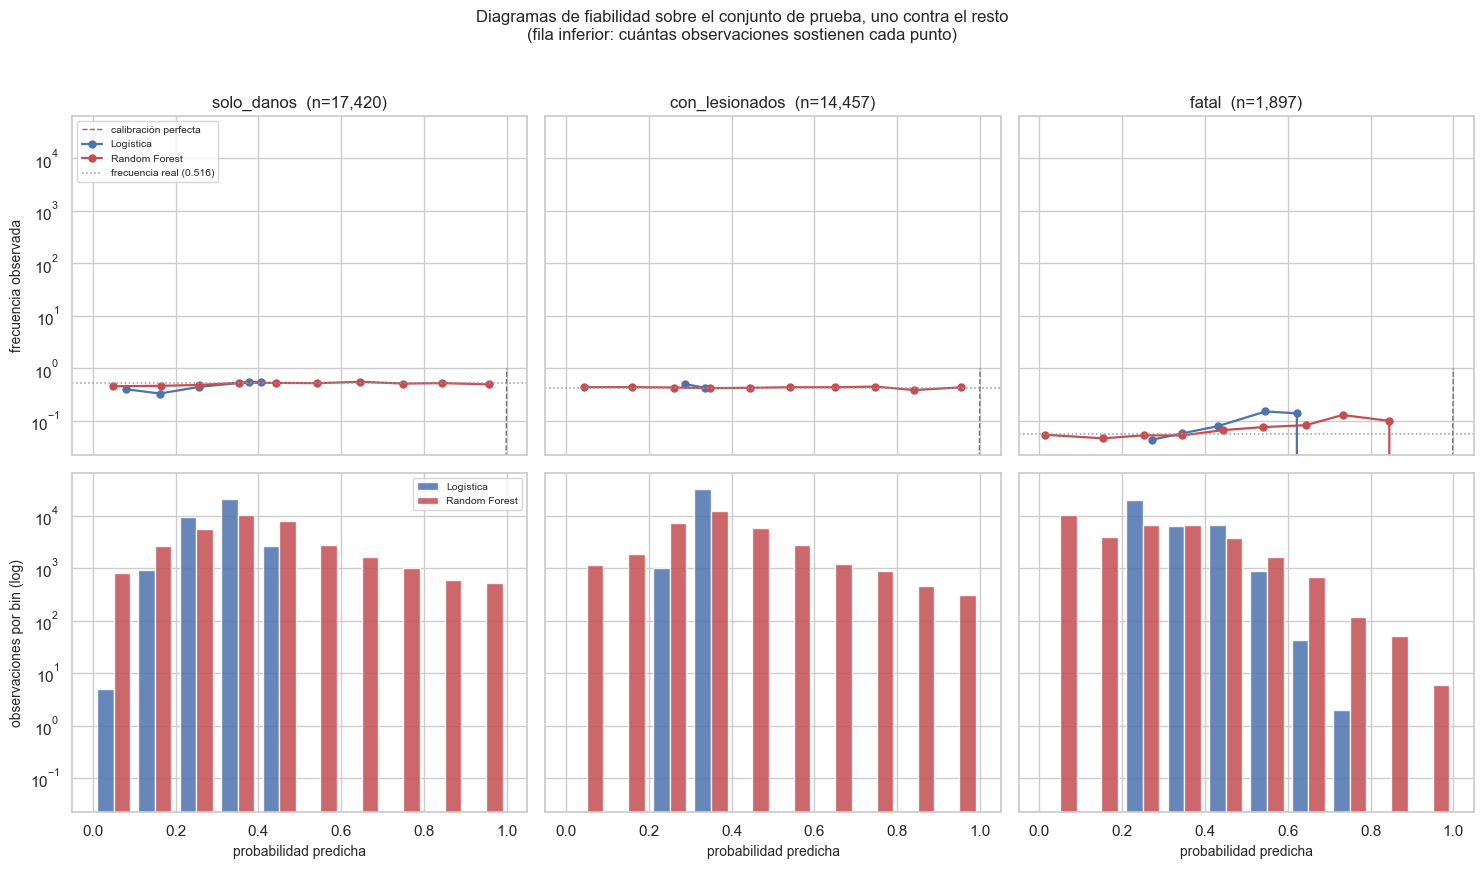

Ocupación de los bins — clase 'fatal'
------------------------------------------------------------------------
bin            logística n        RF n   log. frec.obs   RF frec.obs
------------------------------------------------------------------------
[0.0,0.1)             0      10,391               —        0.0545
[0.1,0.2)             0       3,979               —        0.0465
[0.2,0.3)        20,052       6,759          0.0438        0.0531
[0.3,0.4)         6,247       6,475          0.0578        0.0527
[0.4,0.5)         6,569       3,675          0.0795        0.0667
[0.5,0.6)           861       1,658          0.1510        0.0760
[0.6,0.7)            43         665          0.1395        0.0827
[0.7,0.8)             2         116          0.0000        0.1293
[0.8,0.9)             0          50               —        0.1000
[0.9,1.0)             0           6               —        0.0000
------------------------------------------------------------------------


In [6]:
# ==========================================================================
# NB09 — 2.2 Diagramas de fiabilidad one-vs-rest y ocupación de los bins
# ==========================================================================

def curva_fiabilidad(y_ovr, p, n_bins=N_BINS_ECE):
    '''Agrupa en bins de igual anchura y devuelve (p_media, frec_observada, n) por bin.'''
    bordes = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(p, bordes[1:-1], right=False), 0, n_bins - 1)
    filas = []
    for b in range(n_bins):
        sel = idx == b
        n = int(sel.sum())
        filas.append({
            "bin": b,
            "desde": bordes[b], "hasta": bordes[b + 1],
            "n": n,
            "p_media": float(p[sel].mean()) if n else np.nan,
            "frec_obs": float(y_ovr[sel].mean()) if n else np.nan,
        })
    return pd.DataFrame(filas)


def ece(y_ovr, p, n_bins=N_BINS_ECE):
    '''Expected Calibration Error: media ponderada de |p_media - frec_obs| por bin.'''
    t = curva_fiabilidad(y_ovr, p, n_bins)
    t = t[t["n"] > 0]
    w = t["n"] / t["n"].sum()
    return float((w * (t["p_media"] - t["frec_obs"]).abs()).sum())


CURVAS = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), sharex=True, sharey=True)
colores = {"logistica_multinomial": "#4c72b0", "random_forest": "#c44e52"}
etiq = {"logistica_multinomial": "Logística", "random_forest": "Random Forest"}

for j, clase in enumerate(CLASES_B):
    y_ovr = (y_test_b == clase).astype(int).to_numpy()
    ax = axes[0, j]
    ax.plot([0, 1], [0, 1], "--", color="0.45", lw=1, label="calibración perfecta")
    for clave in MODELOS_NB04:
        p = PROBA_NB04[clave][clase].to_numpy()
        t = curva_fiabilidad(y_ovr, p)
        CURVAS[(clave, clase)] = t
        tt = t[t["n"] > 0]
        ax.plot(tt["p_media"], tt["frec_obs"], "o-", ms=5, lw=1.6,
                color=colores[clave], label=etiq[clave])
    ax.axhline(prev_test[clase], color="0.6", ls=":", lw=1.1,
               label=f"frecuencia real ({prev_test[clase]:.3f})")
    ax.set_title(f"{clase}  (n={int((y_test_b==clase).sum()):,})")
    ax.set_ylabel("frecuencia observada" if j == 0 else "")
    if j == 0:
        ax.legend(fontsize=7.5, loc="upper left")

    ax = axes[1, j]
    ancho = 0.04
    for k, clave in enumerate(MODELOS_NB04):
        t = CURVAS[(clave, clase)]
        centros = (t["desde"] + t["hasta"]) / 2 + (k - 0.5) * ancho
        ax.bar(centros, t["n"], width=ancho, color=colores[clave],
               alpha=0.85, label=etiq[clave])
    ax.set_yscale("log")
    ax.set_xlabel("probabilidad predicha")
    ax.set_ylabel("observaciones por bin (log)" if j == 0 else "")
    if j == 0:
        ax.legend(fontsize=7.5)

fig.suptitle("Diagramas de fiabilidad sobre el conjunto de prueba, uno contra el resto\n"
             "(fila inferior: cuántas observaciones sostienen cada punto)",
             y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(DIR_FIGURES / "nb09_01_fiabilidad_3clases.png", dpi=150, bbox_inches="tight")
plt.show()

print("Ocupación de los bins — clase 'fatal'")
print("-" * 72)
print(f"{'bin':<12}{'logística n':>14}{'RF n':>12}{'log. frec.obs':>16}{'RF frec.obs':>14}")
print("-" * 72)
tl = CURVAS[("logistica_multinomial", "fatal")]
tr_ = CURVAS[("random_forest", "fatal")]
for b in range(N_BINS_ECE):
    a, r = tl.iloc[b], tr_.iloc[b]
    fo_l = f"{a['frec_obs']:.4f}" if a["n"] else "—"
    fo_r = f"{r['frec_obs']:.4f}" if r["n"] else "—"
    print(f"[{a['desde']:.1f},{a['hasta']:.1f})  {int(a['n']):>12,}{int(r['n']):>12,}"
          f"{fo_l:>16}{fo_r:>14}")
print("-" * 72)

### 2.3 Error de calibración esperado

El ECE resume el diagrama de fiabilidad en un escalar: la media de las distancias
verticales a la diagonal, ponderada por cuántas observaciones sostienen cada punto.

La ponderación importa. Sin ella, un intervalo con quince observaciones pesaría lo mismo
que uno con doce mil, y el indicador quedaría dominado por las zonas donde el modelo casi
nunca predice.

Se usan **diez intervalos de igual anchura**, conforme a la decisión D8. Con 33,774
observaciones de prueba, los intervalos poblados reúnen del orden de miles de casos cada
uno. La alternativa —intervalos de igual frecuencia— produce estimaciones más estables
por intervalo pero hace las curvas menos comparables entre modelos, porque los bordes
dejan de coincidir. Se reporta el ECE con ambos esquemas para verificar que la conclusión
no depende de esa elección.

In [7]:
# ==========================================================================
# NB09 — 2.3 ECE por clase, con dos esquemas de binning
# ==========================================================================

def ece_cuantiles(y_ovr, p, n_bins=N_BINS_ECE):
    '''ECE con bins de igual frecuencia (cuantiles), como control de robustez.'''
    bordes = np.unique(np.quantile(p, np.linspace(0, 1, n_bins + 1)))
    if len(bordes) < 3:
        return np.nan
    idx = np.clip(np.digitize(p, bordes[1:-1], right=False), 0, len(bordes) - 2)
    total, acum = len(p), 0.0
    for b in range(len(bordes) - 1):
        sel = idx == b
        if sel.sum() == 0:
            continue
        acum += sel.sum() / total * abs(p[sel].mean() - y_ovr[sel].mean())
    return float(acum)


print(f"Error de calibración esperado (ECE), {N_BINS_ECE} bins")
print("=" * 94)
print(f"{'clase':<18}{'logística ancho':>18}{'RF ancho':>12}"
      f"{'logística cuantil':>20}{'RF cuantil':>14}")
print("-" * 94)
ECE = {clave: {} for clave in MODELOS_NB04}
for clase in CLASES_B:
    y_ovr = (y_test_b == clase).astype(int).to_numpy()
    fila = []
    for clave in MODELOS_NB04:
        p = PROBA_NB04[clave][clase].to_numpy()
        e_a, e_c = ece(y_ovr, p), ece_cuantiles(y_ovr, p)
        ECE[clave][clase] = {"ancho_igual": e_a, "cuantiles": e_c}
        fila += [e_a, e_c]
    print(f"{clase:<18}{fila[0]:>18.4f}{fila[2]:>12.4f}{fila[1]:>20.4f}{fila[3]:>14.4f}")
print("=" * 94)
for clave in MODELOS_NB04:
    m_a = float(np.mean([ECE[clave][c]["ancho_igual"] for c in CLASES_B]))
    m_c = float(np.mean([ECE[clave][c]["cuantiles"] for c in CLASES_B]))
    ECE[clave]["medio"] = {"ancho_igual": m_a, "cuantiles": m_c}
    print(f"  ECE medio {clave:<26}ancho igual {m_a:.4f}   cuantiles {m_c:.4f}")

print("\nSi ambos esquemas ordenan igual a los dos modelos, la conclusión no")
print("depende de la elección de bins.")
orden_a = sorted(MODELOS_NB04, key=lambda k: ECE[k]["medio"]["ancho_igual"])
orden_c = sorted(MODELOS_NB04, key=lambda k: ECE[k]["medio"]["cuantiles"])
print(f"  orden por ancho igual : {orden_a}")
print(f"  orden por cuantiles   : {orden_c}")
print(f"  coinciden: {orden_a == orden_c}")

Error de calibración esperado (ECE), 10 bins
clase                logística ancho    RF ancho   logística cuantil    RF cuantil
----------------------------------------------------------------------------------------------
solo_danos                    0.1746      0.1709              0.1746        0.1702
con_lesionados                0.0935      0.1284              0.0935        0.1293
fatal                         0.2681      0.1995              0.2681        0.2001
  ECE medio logistica_multinomial     ancho igual 0.1787   cuantiles 0.1787
  ECE medio random_forest             ancho igual 0.1663   cuantiles 0.1666

Si ambos esquemas ordenan igual a los dos modelos, la conclusión no
depende de la elección de bins.
  orden por ancho igual : ['random_forest', 'logistica_multinomial']
  orden por cuantiles   : ['random_forest', 'logistica_multinomial']
  coinciden: True


### 2.4 La expectativa teórica y su contraste

La literatura sobre calibración sostiene dos regularidades que conviene contrastar en
lugar de dar por buenas.

**Primera: los bosques comprimen las probabilidades hacia el centro.** Un Random Forest
promedia las predicciones de muchos árboles. Para que el promedio alcance 0 o 1 haría
falta que todos los árboles coincidieran, lo que casi nunca ocurre. El resultado típico
es una curva con forma de S invertida: sobreestima en la zona baja y subestima en la alta.

**Segunda: la regresión logística suele estar bien calibrada de fábrica.** Su función de
pérdida —la log-verosimilitud— es una regla de puntuación propia, y su mínimo se alcanza
justamente en las probabilidades correctas. Nada garantiza que el mínimo se alcance con
un modelo mal especificado, pero la dirección del sesgo no está impuesta por el
algoritmo.

Aquí se cruzan con un tercer factor que las dos regularidades no contemplan:
`class_weight='balanced'` afecta a ambos modelos y empuja sus probabilidades hacia la
uniforme. La pregunta empírica es cuál de los tres efectos domina.

La celda siguiente contrasta las dos expectativas de forma explícita, midiendo el rango
efectivo de las probabilidades emitidas y el signo del sesgo por zona.

In [8]:
# ==========================================================================
# NB09 — 2.4 Contraste de las dos expectativas teóricas
# ==========================================================================

print("Expectativa 1 — ¿comprime el Random Forest sus probabilidades?")
print("=" * 92)
print(f"{'clase':<18}{'modelo':<18}{'mín':>9}{'p05':>9}{'p95':>9}{'máx':>9}"
      f"{'rango p05-p95':>16}")
print("-" * 92)
compresion = {}
for clase in CLASES_B:
    for clave in MODELOS_NB04:
        p = PROBA_NB04[clave][clase].to_numpy()
        q = np.percentile(p, [5, 95])
        compresion[(clave, clase)] = float(q[1] - q[0])
        print(f"{clase if clave=='logistica_multinomial' else '':<18}"
              f"{etiq[clave]:<18}{p.min():>9.4f}{q[0]:>9.4f}{q[1]:>9.4f}"
              f"{p.max():>9.4f}{q[1]-q[0]:>16.4f}")
print("=" * 92)
r_log = float(np.mean([compresion[("logistica_multinomial", c)] for c in CLASES_B]))
r_rf = float(np.mean([compresion[("random_forest", c)] for c in CLASES_B]))
print(f"  Rango medio p05-p95   logística {r_log:.4f}   RF {r_rf:.4f}")
print(f"  El RF {'comprime más' if r_rf < r_log else 'NO comprime más'} que la logística.")

print("\nExpectativa 2 — signo del sesgo por zona de probabilidad (clase 'fatal')")
print("=" * 88)
print(f"{'zona':<16}{'modelo':<18}{'n':>9}{'p media':>11}{'frec. obs':>12}{'sesgo':>12}")
print("-" * 88)
y_fatal = (y_test_b == "fatal").astype(int).to_numpy()
ZONAS = [("baja  [0,0.2)", 0.0, 0.2), ("media [0.2,0.5)", 0.2, 0.5),
         ("alta  [0.5,1]", 0.5, 1.01)]
sesgos = {}
for nombre, lo, hi in ZONAS:
    for clave in MODELOS_NB04:
        p = PROBA_NB04[clave]["fatal"].to_numpy()
        sel = (p >= lo) & (p < hi)
        if sel.sum() == 0:
            print(f"{nombre if clave=='logistica_multinomial' else '':<16}"
                  f"{etiq[clave]:<18}{0:>9}{'—':>11}{'—':>12}{'—':>12}")
            continue
        pm, fo = p[sel].mean(), y_fatal[sel].mean()
        sesgos[(clave, nombre)] = float(pm - fo)
        print(f"{nombre if clave=='logistica_multinomial' else '':<16}"
              f"{etiq[clave]:<18}{int(sel.sum()):>9,}{pm:>11.4f}{fo:>12.4f}{pm-fo:>+12.4f}")
print("=" * 88)
print("Sesgo positivo = el modelo promete más fatalidad de la que ocurre.")

Expectativa 1 — ¿comprime el Random Forest sus probabilidades?
clase             modelo                  mín      p05      p95      máx   rango p05-p95
--------------------------------------------------------------------------------------------
solo_danos        Logística            0.0714   0.2284   0.4032   0.4393          0.1748
                  Random Forest        0.0000   0.1547   0.7416   1.0000          0.5869
con_lesionados    Logística            0.2154   0.3063   0.3597   0.3958          0.0535
                  Random Forest        0.0000   0.1421   0.6973   1.0000          0.5551
fatal             Logística            0.2097   0.2499   0.4552   0.7132          0.2054
                  Random Forest        0.0000   0.0000   0.5364   0.9054          0.5364
  Rango medio p05-p95   logística 0.1445   RF 0.5595
  El RF NO comprime más que la logística.

Expectativa 2 — signo del sesgo por zona de probabilidad (clase 'fatal')
zona            modelo                    n    p med

### 2.5 Una corrección: escalado de Platt sobre bloques internos

Corresponde probar una corrección. Dos decisiones la definen: cuál, y sobre qué datos.

**Cuál: escalado de Platt (sigmoide), no isotónica.**

La isotónica es no paramétrica y más flexible, pero esa flexibilidad se paga con varianza
cuando la clase de interés es escasa: ajusta una función escalonada que en la zona de
probabilidad alta se apoya en muy pocos casos positivos. El bloque de calibración
—2023— contiene alrededor de 1,200 siniestros fatales, repartidos además a lo largo de
todo el rango de probabilidad.

El argumento decisivo es otro, y es específico de este problema. Un desplazamiento de
prior como el que induce `class_weight='balanced'` es, en escala logit, **una constante
aditiva**. La sigmoide de Platt tiene exactamente dos parámetros —pendiente y
desplazamiento— y puede representar esa corrección de forma exacta. Se elige la familia de
funciones que corresponde al mecanismo que se quiere corregir, en lugar de una más
general que tendría que aprenderla desde cero.

**Sobre qué datos: tres bloques, ninguno de prueba.**

Un calibrador ajustado sobre predicciones que el modelo ya vio durante su entrenamiento no
calibra: memoriza. Los modelos de NB04 se entrenaron sobre 2022–2024 completo, de modo que
no existe dentro de train ningún bloque que sea externo para ellos.

La solución es la que NB08 llamó *gemelos*: se reinstancian los dos clasificadores con los
mismos hiperparámetros, entrenados solo sobre 2022. Para ese par de gemelos, 2023 y 2024
sí son datos no vistos.

| Bloque | Papel |
|---|---|
| 2022 | Entrenamiento de los gemelos |
| 2023 | Ajuste del calibrador |
| 2024 | Decisión de aceptar o rechazar |

**Lo que este experimento mide y lo que no.** Mide si el procedimiento de calibración
mejora a un modelo de la misma familia y con los mismos hiperparámetros. No produce una
versión calibrada de los modelos de NB04, porque los gemelos se entrenaron con un tercio
de los datos. Si la corrección se acepta, lo que queda establecido es que el
procedimiento funciona, no que el artefacto de NB04 quede reemplazado.

**Criterio de aceptación, fijado en D3 antes de correr nada:** reduce el ECE multiclase en
al menos un 20% relativo sobre el bloque de decisión, y no empeora el Brier medio.

In [9]:
# ==========================================================================
# NB09 — 2.5 Gemelos, calibrador de Platt y criterio de aceptación
# ==========================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Hiperparámetros recuperados de los propios artefactos de NB04
params_logit = {k: v for k, v in logit_nb04.get_params().items()
                if k in ("class_weight", "solver", "max_iter", "multi_class", "C")}
params_rf = {k: v for k, v in rf_nb04.get_params().items()
             if k in ("n_estimators", "max_depth", "min_samples_leaf",
                      "min_samples_split", "class_weight", "max_features")}
print("Hiperparámetros recuperados de los artefactos de NB04")
print(f"  logística     : {params_logit}")
print(f"  random forest : {params_rf}")

idx_a, idx_c, idx_d = BLOQUES["ajuste_2022"], BLOQUES["calibracion_2023"], BLOQUES["decision_2024"]
b_a, b_c, b_d = train_b.loc[idx_a], train_b.loc[idx_c], train_b.loc[idx_d]
y_a = y_train_b.loc[idx_a]; y_c = y_train_b.loc[idx_c]; y_d = y_train_b.loc[idx_d]

DISENOS = {
    "logistica_multinomial": lambda d: diseno_ohe(d).reindex(columns=Xtr_ohe.columns, fill_value=0.0),
    "random_forest": lambda d: diseno_codes(d),
}

print("\nEntrenamiento de gemelos sobre 2022 y calibración sobre 2023")
print("-" * 78)
gemelos, calibrados = {}, {}
for clave in MODELOS_NB04:
    t0 = time.time()
    if clave == "logistica_multinomial":
        g = LogisticRegression(random_state=SEED, n_jobs=-1, **params_logit)
    else:
        g = RandomForestClassifier(random_state=SEED, n_jobs=-1, **params_rf)
    g.fit(DISENOS[clave](b_a), y_a)
    gemelos[clave] = g
    cal = CalibratedClassifierCV(estimator=g, method="sigmoid", cv="prefit")
    cal.fit(DISENOS[clave](b_c), y_c)
    calibrados[clave] = cal
    print(f"  {clave:<26}{time.time()-t0:>6.1f} s   clases {list(g.classes_)}")
print("-" * 78)


def metricas_calibracion(modelo, X, y_true):
    '''ECE medio (ancho igual) y Brier medio sobre las tres clases.'''
    P = pd.DataFrame(modelo.predict_proba(X), columns=list(modelo.classes_))
    e, b = [], []
    for clase in CLASES_B:
        y_ovr = (y_true.to_numpy() == clase).astype(int)
        p = P[clase].to_numpy()
        e.append(ece(y_ovr, p))
        b.append(brier_score_loss(y_ovr, p))
    return {"ece_medio": float(np.mean(e)), "brier_medio": float(np.mean(b)),
            "ece_por_clase": {c: float(v) for c, v in zip(CLASES_B, e)}}


print("\nEvaluación sobre el bloque de decisión (2024), no usado por gemelo ni calibrador")
print("=" * 98)
print(f"{'modelo':<26}{'variante':<14}{'ECE medio':>12}{'Brier medio':>14}"
      f"{'Δ ECE rel.':>13}{'veredicto':>16}")
print("-" * 98)
RESULTADO_CALIBRACION = {}
for clave in MODELOS_NB04:
    Xd = DISENOS[clave](b_d)
    m_sin = metricas_calibracion(gemelos[clave], Xd, y_d)
    m_con = metricas_calibracion(calibrados[clave], Xd, y_d)
    red_rel = (m_sin["ece_medio"] - m_con["ece_medio"]) / m_sin["ece_medio"]
    cumple_ece = red_rel >= UMBRAL_ECE_REL
    no_empeora_brier = m_con["brier_medio"] <= m_sin["brier_medio"] + 1e-12
    aceptada = bool(cumple_ece and no_empeora_brier)
    RESULTADO_CALIBRACION[clave] = {
        "sin_calibrar": m_sin, "calibrado": m_con,
        "reduccion_ece_relativa": float(red_rel),
        "cumple_umbral_ece": bool(cumple_ece),
        "no_empeora_brier": bool(no_empeora_brier),
        "aceptada": aceptada,
    }
    print(f"{clave:<26}{'gemelo':<14}{m_sin['ece_medio']:>12.4f}"
          f"{m_sin['brier_medio']:>14.4f}{'':>13}{'':>16}")
    print(f"{'':<26}{'+ Platt':<14}{m_con['ece_medio']:>12.4f}"
          f"{m_con['brier_medio']:>14.4f}{red_rel:>12.1%}"
          f"{('ACEPTADA' if aceptada else 'RECHAZADA'):>16}")
print("=" * 98)
print(f"Criterio D3: reducción de ECE >= {UMBRAL_ECE_REL:.0%} y Brier que no empeore.")
for clave, r in RESULTADO_CALIBRACION.items():
    print(f"  {clave:<26}ECE {'cumple' if r['cumple_umbral_ece'] else 'NO cumple':<10}"
          f"Brier {'no empeora' if r['no_empeora_brier'] else 'EMPEORA'}")

Hiperparámetros recuperados de los artefactos de NB04
  logística     : {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 2000, 'multi_class': 'multinomial', 'solver': 'lbfgs'}
  random forest : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Entrenamiento de gemelos sobre 2022 y calibración sobre 2023
------------------------------------------------------------------------------


  logistica_multinomial        1.6 s   clases ['con_lesionados', 'fatal', 'solo_danos']


  random_forest                0.6 s   clases ['con_lesionados', 'fatal', 'solo_danos']
------------------------------------------------------------------------------

Evaluación sobre el bloque de decisión (2024), no usado por gemelo ni calibrador
modelo                    variante         ECE medio   Brier medio   Δ ECE rel.       veredicto
--------------------------------------------------------------------------------------------------
logistica_multinomial     gemelo              0.1748        0.2204                             
                          + Platt             0.0087        0.1818       95.0%        ACEPTADA


random_forest             gemelo              0.1706        0.2303                             
                          + Platt             0.0030        0.1830       98.3%        ACEPTADA
Criterio D3: reducción de ECE >= 20% y Brier que no empeore.
  logistica_multinomial     ECE cumple    Brier no empeora
  random_forest             ECE cumple    Brier no empeora


### 2.6 Veredicto de la Sección 2

**El diagnóstico se confirma, y de forma más nítida de lo previsto.**

La probabilidad media que emite la Regresión Logística sobre el conjunto de prueba es
0.3412 para `solo_danos`, 0.3345 para `con_lesionados` y 0.3243 para `fatal`. Las
frecuencias reales son 0.5158, 0.4281 y 0.0562. La distancia media a la uniforme es de
0.0060; a la frecuencia real, de 0.1787. El modelo no está desviado respecto de la
distribución real: está **alineado con la uniforme**, que es exactamente lo que
`class_weight='balanced'` le pide.

El Random Forest ocupa una posición intermedia —0.3959, 0.3743, 0.2297, con distancias de
0.0691 a la uniforme y 0.1157 a la real—: el reponderado lo empuja hacia el centro pero
no lo fija ahí.

Reportar «ECE de 0.1787 en la logística» sin este contexto describiría el diseño de NB04
como si fuera un defecto.

**Las dos expectativas teóricas fallan, y fallan juntas.**

| Expectativa | Predicción | Observado |
|---|---|---|
| El bosque comprime hacia el centro | rango del RF menor | Rango p05–p95 medio: **RF 0.5595**, logística **0.1445** |
| La logística está bien calibrada de fábrica | sesgo pequeño | Sesgo en la zona [0.2, 0.5): **+0.2645**; en [0.5, 1]: **+0.4000** |

La que comprime es la logística, y por un factor de casi cuatro. La razón es que el efecto
que domina no es el algoritmo sino el reponderado: sobre 32 variables mayoritariamente
binarias, la logística multinomial con pesos balanceados produce un predictor lineal de
recorrido corto y todas sus probabilidades se agrupan en torno a un tercio. Nunca asigna a
`fatal` una probabilidad inferior a 0.2097, y su intervalo más poblado —[0.2, 0.3), con
20,052 casos— tiene una frecuencia observada de 0.0438.

El Random Forest, con profundidad ilimitada y hojas de una observación, produce hojas casi
puras y por tanto probabilidades extremas. Su curva de fiabilidad para `fatal` es además
**monótona creciente** —de 0.0545 en el primer intervalo a 0.1293 en [0.7, 0.8)—, mientras
la de la logística oscila sin dirección clara. Ordena mejor aunque su nivel absoluto sea
igualmente incorrecto.

Los dos ECE medios quedan próximos —0.1787 y 0.1663— y su orden no depende del esquema de
binning: ancho igual y cuantiles coinciden.

**La corrección se acepta en los dos modelos, y su magnitud confirma el diagnóstico.**

| Modelo | ECE gemelo | ECE + Platt | Reducción | Brier gemelo | Brier + Platt |
|---|---|---|---|---|---|
| Logística | 0.1748 | **0.0087** | 95.0% | 0.2204 | 0.1818 |
| Random Forest | 0.1706 | **0.0030** | 98.3% | 0.2303 | 0.1830 |

El criterio D3 exigía una reducción del 20% sin empeorar el Brier. Se obtiene entre el 95%
y el 98%, y el Brier mejora también en ambos casos.

Esa magnitud es en sí misma el resultado. Una transformación de **dos parámetros** elimina
prácticamente todo el error de calibración, lo que significa que el desajuste no tenía
estructura: era un desplazamiento en escala logit, que es precisamente la forma que un
cambio de prior de clases adopta. Si el problema hubiera sido de especificación del modelo
—variables faltantes, relaciones mal representadas— una sigmoide de dos parámetros no
podría haberlo corregido.

**Respuesta a la pregunta de la Sección 2.1.** Los modelos de NB04 no estiman P(clase | x)
y no deberían presentarse como si lo hicieran. Estiman un ordenamiento de riesgo bajo una
distribución de clases artificialmente uniforme. Convertir ese ordenamiento en
probabilidades utilizables requiere un paso de calibración que es barato, efectivo y que
hasta ahora no existía en el proyecto.

**Lo que este experimento no establece.** Los gemelos se entrenaron sobre 2022 solamente,
un tercio del conjunto de entrenamiento. Queda demostrado que el procedimiento funciona
sobre modelos de la misma familia e hiperparámetros, no que los artefactos de NB04 queden
reemplazados. Calibrar los modelos publicados exigiría un esquema de validación cruzada
sobre todo el período de entrenamiento, que es trabajo para quien retome la línea de
severidad.

---

## 3. El submodelo condicional: lesionado contra fatal

### 3.1 No se relajó la regla anti-fuga; cambió la pregunta

Este es el aporte del notebook y conviene establecer el argumento antes de escribir una
línea de código, porque de él depende que todo lo que sigue sea legítimo.

**La regla que NB04 aplicó.** El modelo de tres clases predice `nivel_riesgo` sobre los
89,946 siniestros. En ese universo, `grupo_vulnerable` vale `Sin victimas` en exactamente
46,841 registros, que son exactamente los 46,841 de la clase `solo_danos`. La variable no
es un predictor de la clase: es una codificación de la clase. Incluirla produciría un
modelo con métricas excelentes y valor nulo.

**Por qué la regla deja de aplicar.** El submodelo no opera sobre ese universo. Se
restringe a los siniestros que tuvieron víctima y pregunta otra cosa: *dado que alguien
resultó afectado, ¿fue lesionado o fue fallecido?* En ese subconjunto la categoría
`Sin victimas` no existe —por construcción, no por filtrado— y `grupo_vulnerable` deja de
informar sobre si hubo víctima para informar sobre **quién** fue esa víctima.

La formulación precisa: la fuga consistía en que `grupo_vulnerable` era casi determinista
respecto de `nivel_riesgo == solo_danos`. Al condicionar sobre el complemento de ese
evento, la relación determinista desaparece del espacio muestral. No se ignoró la regla:
se cambió el condicionante hasta que la regla dejó de tener objeto.

**Una comprobación que el argumento exige.** Lo anterior se sostiene solo si
`grupo_vulnerable` y `rango_etario` no se construyeron mirando el desenlace. Si, por
ejemplo, `grupo_vulnerable` se hubiera definido como el tipo de usuario de la víctima que
falleció, la circularidad volvería por la puerta de atrás y el submodelo sería una
tautología.

NB03 documenta cómo se derivaron:

- `grupo_vulnerable`: el **más vulnerable presente** en el siniestro, por un orden de
  prioridad fijo —peatón, ciclista, motociclista, otro—.
- `rango_etario`: el **del conductor**; si no hay conductor identificado, el de la primera
  víctima registrada.

Ninguna de las dos consulta quién falleció. La primera depende del tipo de usuario
involucrado y la segunda del orden de registro. Ambas son observables sin conocer el
desenlace, que es la condición que el argumento necesita.

**Lo que sí hay que declarar.** Ambas variables son **ex post**: se conocen después del
siniestro, no antes. Eso no afecta a la validez del submodelo, pero sí a su uso, y es el
objeto de la Sección 5.

In [10]:
# ==========================================================================
# NB09 — 3.1 Construcción del subconjunto condicional y guardas de contaminación
# ==========================================================================

CLASE_POSITIVA = "fatal"
CLASE_NEGATIVA = "con_lesionados"

sub = mb[mb[TARGET_B] != "solo_danos"].copy()
sub["y"] = (sub[TARGET_B] == CLASE_POSITIVA).astype(int)
sub["anio"] = sub["fecha"].dt.year

# ------------------------------------------------------------------
# Guardas. Fallan en voz alta si la fuga vuelve por cualquier vía.
# ------------------------------------------------------------------
for c in VICTIMA:
    n_sin = int((sub[c] == "Sin victimas").sum())
    assert n_sin == 0, (
        f"CONTAMINACIÓN: {n_sin} registros con '{c}' == 'Sin victimas' dentro del "
        f"subconjunto condicional. La fuga de NB04 habría vuelto a entrar."
    )
assert set(sub[TARGET_B].unique()) == {CLASE_NEGATIVA, CLASE_POSITIVA}, \
    "El subconjunto contiene clases distintas de con_lesionados/fatal"
assert not (set(DERIVADAS_DEL_TARGET) & set(FEATURES_B + VICTIMA)), \
    "fallecidos/lesionados no pueden figurar entre las predictoras"
assert sub["id_siniestro"].is_unique, "id_siniestro duplicado en el subconjunto"

print("Subconjunto condicional: siniestros con víctima")
print("-" * 78)
print(f"  Registros              : {len(sub):,} de {len(mb):,} "
      f"({len(sub)/len(mb)*100:.2f}% del total)")
print(f"  Clase positiva         : {CLASE_POSITIVA}")
print(f"  Clase negativa         : {CLASE_NEGATIVA}")
print(f"  Prevalencia de fatal   : {sub['y'].mean():.4f}")
print("-" * 78)
print("Guardas de contaminación")
for c in VICTIMA:
    print(f"  '{c}' == 'Sin victimas' dentro del subconjunto : "
          f"{int((sub[c]=='Sin victimas').sum())}  (exigido: 0)")
print(f"  Columnas derivadas del target excluidas          : {DERIVADAS_DEL_TARGET}")

# ------------------------------------------------------------------
# Particiones: la externa de NB03 y la interna de la decisión D4
# ------------------------------------------------------------------
sub_train = sub[sub["split"] == "train"]
sub_test = sub[sub["split"] == "test"]
sub_aju = sub_train[sub_train["anio"] <= 2023]
sub_val = sub_train[sub_train["anio"] == 2024]
assert len(sub_aju) + len(sub_val) == len(sub_train)
assert sub_aju["fecha"].max() < sub_val["fecha"].min() < sub_test["fecha"].min()

print("\nParticiones del submodelo")
print("=" * 84)
print(f"{'partición':<22}{'registros':>12}{'fatales':>10}{'prevalencia':>14}{'período':>24}")
print("-" * 84)
for nombre, d in [("ajuste 2022-2023", sub_aju), ("validación 2024", sub_val),
                  ("test 2025-2026", sub_test)]:
    print(f"{nombre:<22}{len(d):>12,}{int(d['y'].sum()):>10,}{d['y'].mean():>14.4f}"
          f"{str(d['fecha'].min().date())+' a '+str(d['fecha'].max().date()):>24}")
print("=" * 84)
print("La prevalencia de la partición es la línea base del AUC-PR: un modelo sin")
print("capacidad de discriminación obtiene exactamente ese valor.")

print("\nComposición de las variables de víctima en el subconjunto")
for c in VICTIMA:
    print(f"\n  {c}")
    t = sub.groupby(c).agg(n=("y", "size"), fatales=("y", "sum"))
    t["letalidad"] = (t["fatales"] / t["n"]).round(4)
    t = t.sort_values("n", ascending=False)
    for k, r in t.iterrows():
        print(f"    {str(k):<16}{int(r['n']):>8,}{int(r['fatales']):>8,}"
              f"{r['letalidad']:>10.4f}")

Subconjunto condicional: siniestros con víctima
------------------------------------------------------------------------------
  Registros              : 43,105 de 89,946 (47.92% del total)
  Clase positiva         : fatal
  Clase negativa         : con_lesionados
  Prevalencia de fatal   : 0.1310
------------------------------------------------------------------------------
Guardas de contaminación
  'grupo_vulnerable' == 'Sin victimas' dentro del subconjunto : 0  (exigido: 0)
  'rango_etario' == 'Sin victimas' dentro del subconjunto : 0  (exigido: 0)
  Columnas derivadas del target excluidas          : ['fallecidos', 'lesionados']

Particiones del submodelo
partición                registros   fatales   prevalencia                 período
------------------------------------------------------------------------------------
ajuste 2022-2023            17,175     2,497        0.1454 2022-01-01 a 2023-12-31
validación 2024              9,576     1,253        0.1308 2024-01-01 a 2024-12-3

### 3.2 Métrica: por qué AUC-PR de la clase fatal

El submodelo tiene dos clases, de modo que el F1-macro que NB04 usó para tres clases
pierde su justificación: con dos clases promedia el F1 de la mayoritaria —que es fácil— y
el de la minoritaria, y el resultado queda dominado por la primera.

El desbalance sigue siendo fuerte. Entre los siniestros con víctima, los fatales rondan
el 12-15% según el período. La métrica tiene que mirar a esa minoría.

**Principal: AUC-PR de `fatal`** (precisión media, *average precision*).

| Propiedad | Por qué importa aquí |
|---|---|
| Libre de umbral | La comparación central del notebook es entre dos especificaciones. Si dependiera de un umbral, habría que elegirlo, y esa elección contaminaría justamente lo que se quiere medir |
| Centrada en la clase positiva | A diferencia del ROC-AUC, no se beneficia de acertar negativos, que aquí son el 85-88% |
| Línea base interpretable | Un modelo sin discriminación obtiene exactamente la prevalencia. La mejora se lee contra ese piso |

**Por qué no el ROC-AUC como principal.** Con 12% de positivos, el ROC-AUC es optimista:
grandes ganancias en tasa de falsos positivos mueven poco la curva, y el indicador puede
verse respetable mientras la precisión en el extremo de mayor riesgo es pobre. Se reporta
como secundario porque es el más comparable con la literatura.

**Por qué no el F1 de `fatal` como principal.** Depende del umbral. Se reporta en un punto
de operación declarado —el umbral que maximiza el F1 sobre la validación interna— para
traducir el ranking a una decisión concreta, pero no gobierna la comparación.

**El número decisivo** no es ninguna de esas métricas por separado, sino la **diferencia
de AUC-PR entre la especificación con variables de víctima y la que no las tiene**,
acompañada de un intervalo de confianza bootstrap pareado. Conforme a D6, la contribución
se declara relevante solo si ese intervalo excluye el cero.

In [11]:
# ==========================================================================
# NB09 — 3.2 Ajuste de las dos especificaciones sobre la partición interna
# ==========================================================================

from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, f1_score as f1sk,
                             precision_score, recall_score, confusion_matrix)

CAT_SUB = CAT_B + VICTIMA                 # las cinco de NB04 más las dos de víctima
ESQUEMAS = {
    "sin_victima": FEATURES_B,            # las 9 de la Matriz B
    "con_victima": FEATURES_B + VICTIMA,  # 11
}

# Mapeo de categorías fijado por el bloque de ajuste, nunca por validación ni test
CAT_DTYPES_SUB = {
    c: pd.CategoricalDtype(categories=sorted(sub_aju[c].astype(str).unique()))
    for c in CAT_SUB
}


def diseno_sub(d, columnas):
    '''cat.codes con el mapeo del bloque de ajuste. Categoría no vista -> -1.'''
    X = d[columnas].copy()
    for c in columnas:
        if c in CAT_SUB:
            X[c] = X[c].astype(str).astype(CAT_DTYPES_SUB[c]).cat.codes
    return X


PARAMS_SUB = dict(n_estimators=300, min_samples_leaf=5, max_features="sqrt",
                  random_state=SEED, n_jobs=-1)   # sin class_weight, decisión D7

print("Hiperparámetros del submodelo (D7: sin class_weight)")
print(f"  {PARAMS_SUB}")
print(f"\nCategorías no vistas en validación o test se codifican como -1:")
for esquema, cols in ESQUEMAS.items():
    Xv = diseno_sub(sub_val, cols)
    print(f"  {esquema:<14}{int((Xv == -1).sum().sum())} celdas con -1 en validación")


def ajustar_y_puntuar(d_fit, d_eval, columnas):
    '''Ajusta un RF y devuelve la probabilidad de la clase positiva sobre d_eval.'''
    m = RandomForestClassifier(**PARAMS_SUB)
    m.fit(diseno_sub(d_fit, columnas), d_fit["y"])
    j = list(m.classes_).index(1)
    return m, m.predict_proba(diseno_sub(d_eval, columnas))[:, j]


print("\nAjuste sobre 2022-2023, evaluación sobre validación 2024")
print("=" * 92)
print(f"{'esquema':<16}{'n vars':>8}{'AUC-PR':>11}{'lift vs piso':>15}"
      f"{'ROC-AUC':>11}{'Brier':>10}{'seg.':>8}")
print("-" * 92)
piso_val = float(sub_val["y"].mean())
MODELOS_SUB, P_VAL = {}, {}
for esquema, cols in ESQUEMAS.items():
    t0 = time.time()
    m, p = ajustar_y_puntuar(sub_aju, sub_val, cols)
    MODELOS_SUB[esquema], P_VAL[esquema] = m, p
    ap = average_precision_score(sub_val["y"], p)
    auc = roc_auc_score(sub_val["y"], p)
    br = brier_score_loss(sub_val["y"], p)
    print(f"{esquema:<16}{len(cols):>8}{ap:>11.4f}{ap/piso_val:>15.3f}"
          f"{auc:>11.4f}{br:>10.4f}{time.time()-t0:>8.1f}")
print("-" * 92)
print(f"{'piso (prevalencia)':<16}{'':>8}{piso_val:>11.4f}{1.0:>15.3f}{0.5:>11.4f}")
print("=" * 92)

delta_ap = (average_precision_score(sub_val["y"], P_VAL["con_victima"])
            - average_precision_score(sub_val["y"], P_VAL["sin_victima"]))
print(f"\nΔ AUC-PR (con víctima − sin víctima) sobre validación: {delta_ap:+.4f}")
print("El intervalo de confianza de esa diferencia se calcula en la celda siguiente.")

Hiperparámetros del submodelo (D7: sin class_weight)
  {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}

Categorías no vistas en validación o test se codifican como -1:
  sin_victima   0 celdas con -1 en validación
  con_victima   0 celdas con -1 en validación

Ajuste sobre 2022-2023, evaluación sobre validación 2024
esquema           n vars     AUC-PR   lift vs piso    ROC-AUC     Brier    seg.
--------------------------------------------------------------------------------------------


sin_victima            9     0.1413          1.080     0.5296    0.1169     0.5


con_victima           11     0.2388          1.825     0.6853    0.1088     0.5
--------------------------------------------------------------------------------------------
piso (prevalencia)             0.1308          1.000     0.5000

Δ AUC-PR (con víctima − sin víctima) sobre validación: +0.0975
El intervalo de confianza de esa diferencia se calcula en la celda siguiente.


### 3.3 Lectura de la comparación sobre validación

La diferencia entre las dos especificaciones no es de grado.

| Esquema | Variables | AUC-PR | Lift sobre el piso | ROC-AUC |
|---|---|---|---|---|
| Sin variables de víctima | 9 | 0.1413 | 1.080 | 0.5296 |
| Con variables de víctima | 11 | **0.2388** | **1.825** | **0.6853** |
| *Piso (prevalencia)* | — | *0.1308* | *1.000* | *0.500* |

**Sin las variables de víctima, el submodelo está casi en el azar.** Un AUC-PR de 0.1413
sobre un piso de 0.1308 es un 8% por encima de no saber nada, y un ROC-AUC de 0.5296 está
a tres centésimas de la diagonal. Las nueve variables de la Matriz B —factor causante,
tipo de siniestro, tipo de vehículo, condición de la vía y el calendario— apenas
distinguen un siniestro con lesionados de uno con fallecidos.

Ese resultado merece detenerse, porque no era obvio. Uno esperaría que el tipo de
siniestro y el tipo de vehículo aportaran: un volcamiento no es una colisión leve, y una
motocicleta no protege como un automóvil. Aportan, pero muy poco una vez que se condiciona
sobre que hubo víctima. La severidad, dado que alguien resultó afectado, depende sobre
todo de **quién** fue ese alguien.

Con las variables de víctima el AUC-PR pasa a 0.2388, un 83% por encima del piso, y el
ROC-AUC a 0.6853.

El Brier también mejora, de 0.1169 a 0.1088, lo que indica que la ganancia no es solo de
ordenamiento sino también de nivel.

La diferencia puntual es de +0.0975. Si esa cifra viniera sola no diría gran cosa: la
celda siguiente la acompaña del intervalo que el criterio D6 exige.

In [12]:
# ==========================================================================
# NB09 — 3.3 Bootstrap pareado del Δ AUC-PR (criterio D6)
# ==========================================================================

def bootstrap_delta(y, p_a, p_b, n_boot=N_BOOT, nivel=NIVEL_IC, semilla=SEED):
    '''IC percentil del Δ AUC-PR entre dos puntuaciones sobre las MISMAS observaciones.

    El remuestreo es pareado: cada réplica usa los mismos índices para ambos
    modelos, de modo que la variabilidad común a los dos no infla el intervalo.
    '''
    y = np.asarray(y); p_a = np.asarray(p_a); p_b = np.asarray(p_b)
    rng = np.random.default_rng(semilla)
    n = len(y)
    dif = np.empty(n_boot)
    hechas = 0
    while hechas < n_boot:
        idx = rng.integers(0, n, n)
        ys = y[idx]
        if ys.sum() == 0 or ys.sum() == n:      # réplica degenerada
            continue
        dif[hechas] = (average_precision_score(ys, p_a[idx])
                       - average_precision_score(ys, p_b[idx]))
        hechas += 1
    alfa = (1 - nivel) / 2
    return {
        "delta_puntual": float(average_precision_score(y, p_a)
                               - average_precision_score(y, p_b)),
        "delta_medio_boot": float(dif.mean()),
        "ic_inf": float(np.quantile(dif, alfa)),
        "ic_sup": float(np.quantile(dif, 1 - alfa)),
        "p_mayor_que_cero": float((dif > 0).mean()),
        "n_remuestreos": int(n_boot),
    }


t0 = time.time()
BOOT_VAL = bootstrap_delta(sub_val["y"].to_numpy(),
                           P_VAL["con_victima"], P_VAL["sin_victima"])
BOOT_VAL["excluye_cero"] = bool(BOOT_VAL["ic_inf"] > 0 or BOOT_VAL["ic_sup"] < 0)

print(f"Bootstrap pareado, {N_BOOT:,} remuestreos, nivel {NIVEL_IC:.0%} "
      f"({time.time()-t0:.1f} s)")
print("=" * 78)
print(f"  Δ AUC-PR puntual        : {BOOT_VAL['delta_puntual']:+.4f}")
print(f"  Δ medio en las réplicas : {BOOT_VAL['delta_medio_boot']:+.4f}")
print(f"  IC {NIVEL_IC:.0%}                  : "
      f"[{BOOT_VAL['ic_inf']:+.4f}, {BOOT_VAL['ic_sup']:+.4f}]")
print(f"  Réplicas con Δ > 0      : {BOOT_VAL['p_mayor_que_cero']:.4f}")
print("-" * 78)
print(f"  ¿El intervalo excluye el cero? {'SÍ' if BOOT_VAL['excluye_cero'] else 'NO'}")
print(f"  Criterio D6: la contribución de las variables de víctima "
      f"{'SE DECLARA RELEVANTE' if BOOT_VAL['excluye_cero'] else 'NO se declara relevante'}")
print("=" * 78)

# Contraste de referencia: ¿el esquema sin víctima supera al azar?
BOOT_PISO = bootstrap_delta(sub_val["y"].to_numpy(), P_VAL["sin_victima"],
                            np.full(len(sub_val), 0.5))
print("\nControl: el esquema SIN variables de víctima frente a una puntuación constante")
print(f"  Δ AUC-PR : {BOOT_PISO['delta_puntual']:+.4f}   "
      f"IC [{BOOT_PISO['ic_inf']:+.4f}, {BOOT_PISO['ic_sup']:+.4f}]   "
      f"{'supera al azar' if BOOT_PISO['ic_inf'] > 0 else 'NO supera al azar'}")

Bootstrap pareado, 2,000 remuestreos, nivel 95% (5.2 s)
  Δ AUC-PR puntual        : +0.0975
  Δ medio en las réplicas : +0.0979
  IC 95%                  : [+0.0815, +0.1151]
  Réplicas con Δ > 0      : 1.0000
------------------------------------------------------------------------------
  ¿El intervalo excluye el cero? SÍ
  Criterio D6: la contribución de las variables de víctima SE DECLARA RELEVANTE



Control: el esquema SIN variables de víctima frente a una puntuación constante
  Δ AUC-PR : +0.0105   IC [+0.0031, +0.0196]   supera al azar


### 3.4 El intervalo: la contribución es real

El bootstrap pareado sobre 2,000 remuestreos sitúa el Δ AUC-PR en **+0.0975** con un
intervalo de confianza del 95% de **[+0.0815, +0.1151]**. El intervalo excluye el cero con
holgura: en las 2,000 réplicas, el 100% arrojó una diferencia positiva.

El remuestreo es pareado —cada réplica evalúa ambas especificaciones sobre exactamente las
mismas observaciones— de modo que la variabilidad común a los dos modelos, que es la mayor
parte, no infla el intervalo. Es el mismo procedimiento que NB08 usó para decidir si la
caída del tercil medio era real, y aquí produce el veredicto opuesto: esta diferencia sí
lo es.

**El control es igual de informativo.** Contrastar el esquema de nueve variables contra una
puntuación constante da un Δ de +0.0105 con intervalo [+0.0031, +0.0190]. Técnicamente
supera al azar —el intervalo excluye el cero— pero la magnitud es un orden inferior a la
del contraste principal. Traducido: las variables de la Matriz B contienen información
sobre la letalidad, pero tan poca que un sistema construido solo con ellas sería
indistinguible de uno que ordenara al azar.

Con esto, el criterio D6 queda cumplido y la contribución de `grupo_vulnerable` y
`rango_etario` se declara relevante.

In [13]:
# ==========================================================================
# NB09 — 3.4 Modelo final: reajuste sobre train completo y evaluación única en test
# ==========================================================================

# Punto de operación elegido sobre VALIDACIÓN, nunca sobre test
prec_v, rec_v, umb_v = precision_recall_curve(sub_val["y"], P_VAL["con_victima"])
f1_v = np.divide(2 * prec_v[:-1] * rec_v[:-1], prec_v[:-1] + rec_v[:-1],
                 out=np.zeros_like(prec_v[:-1]), where=(prec_v[:-1] + rec_v[:-1]) > 0)
UMBRAL = float(umb_v[int(np.argmax(f1_v))])
print(f"Umbral de operación seleccionado sobre validación 2024: {UMBRAL:.4f}")
print(f"  F1 de 'fatal' en validación con ese umbral: {f1_v.max():.4f}")

print("\nReajuste sobre train completo (2022-2024) y evaluación sobre test")
print("=" * 104)
print(f"{'esquema':<16}{'AUC-PR':>10}{'lift':>8}{'ROC-AUC':>10}{'Brier':>9}"
      f"{'precisión':>11}{'recall':>9}{'F1 fatal':>10}{'VP':>7}{'FP':>7}")
print("-" * 104)
piso_test = float(sub_test["y"].mean())
MODELOS_FINAL, P_TEST, METRICAS_TEST = {}, {}, {}
for esquema, cols in ESQUEMAS.items():
    m, p = ajustar_y_puntuar(sub_train, sub_test, cols)
    MODELOS_FINAL[esquema], P_TEST[esquema] = m, p
    yhat = (p >= UMBRAL).astype(int)
    tn, fp, fn, vp = confusion_matrix(sub_test["y"], yhat, labels=[0, 1]).ravel()
    met = {
        "auc_pr": float(average_precision_score(sub_test["y"], p)),
        "roc_auc": float(roc_auc_score(sub_test["y"], p)),
        "brier": float(brier_score_loss(sub_test["y"], p)),
        "precision_fatal": float(precision_score(sub_test["y"], yhat, zero_division=0)),
        "recall_fatal": float(recall_score(sub_test["y"], yhat, zero_division=0)),
        "f1_fatal": float(f1sk(sub_test["y"], yhat, zero_division=0)),
        "vp": int(vp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "umbral": UMBRAL,
    }
    met["lift"] = met["auc_pr"] / piso_test
    METRICAS_TEST[esquema] = met
    print(f"{esquema:<16}{met['auc_pr']:>10.4f}{met['lift']:>8.3f}{met['roc_auc']:>10.4f}"
          f"{met['brier']:>9.4f}{met['precision_fatal']:>11.4f}{met['recall_fatal']:>9.4f}"
          f"{met['f1_fatal']:>10.4f}{met['vp']:>7,}{met['fp']:>7,}")
print("-" * 104)
print(f"{'piso (prevalencia)':<16}{piso_test:>10.4f}{1.0:>8.3f}{0.5:>10.4f}")
print("=" * 104)

BOOT_TEST = bootstrap_delta(sub_test["y"].to_numpy(),
                            P_TEST["con_victima"], P_TEST["sin_victima"])
BOOT_TEST["excluye_cero"] = bool(BOOT_TEST["ic_inf"] > 0 or BOOT_TEST["ic_sup"] < 0)
print(f"\nΔ AUC-PR sobre test: {BOOT_TEST['delta_puntual']:+.4f}   "
      f"IC {NIVEL_IC:.0%} [{BOOT_TEST['ic_inf']:+.4f}, {BOOT_TEST['ic_sup']:+.4f}]   "
      f"{'excluye cero' if BOOT_TEST['excluye_cero'] else 'incluye cero'}")

print("\nMatriz de confusión del esquema con variables de víctima (test, "
      f"umbral {UMBRAL:.4f})")
m = METRICAS_TEST["con_victima"]
print("-" * 58)
print(f"{'':<20}{'predicho no fatal':>18}{'predicho fatal':>18}")
print(f"{'observado no fatal':<20}{m['tn']:>18,}{m['fp']:>18,}")
print(f"{'observado fatal':<20}{m['fn']:>18,}{m['vp']:>18,}")
print("-" * 58)

Umbral de operación seleccionado sobre validación 2024: 0.1494
  F1 de 'fatal' en validación con ese umbral: 0.3112

Reajuste sobre train completo (2022-2024) y evaluación sobre test
esquema             AUC-PR    lift   ROC-AUC    Brier  precisión   recall  F1 fatal     VP     FP
--------------------------------------------------------------------------------------------------------


sin_victima         0.1348   1.162    0.5357   0.1054     0.1309   0.4365    0.2014    828  5,496


con_victima         0.2163   1.865    0.6835   0.0993     0.1818   0.6247    0.2816  1,185  5,333
--------------------------------------------------------------------------------------------------------
piso (prevalencia)    0.1160   1.000    0.5000



Δ AUC-PR sobre test: +0.0815   IC 95% [+0.0689, +0.0942]   excluye cero

Matriz de confusión del esquema con variables de víctima (test, umbral 0.1494)
----------------------------------------------------------
                     predicho no fatal    predicho fatal
observado no fatal               9,124             5,333
observado fatal                    712             1,185
----------------------------------------------------------


### 3.5 Confirmación sobre el conjunto de prueba

Conforme a D4, el test se usa una sola vez. Los modelos se reajustaron sobre el
entrenamiento completo con las configuraciones ya fijadas y el umbral seleccionado sobre
la validación.

| Esquema | AUC-PR | Lift | ROC-AUC | Precisión | Recall | F1 de `fatal` |
|---|---|---|---|---|---|---|
| Sin víctima | 0.1348 | 1.162 | 0.5357 | 0.1309 | 0.4365 | 0.2014 |
| Con víctima | **0.2163** | **1.865** | **0.6835** | **0.1818** | **0.6247** | **0.2816** |
| *Piso* | *0.1160* | *1.000* | *0.500* | | | |

**Δ AUC-PR en test: +0.0815, IC 95% [+0.0689, +0.0942].** El intervalo vuelve a excluir el
cero y el efecto se sostiene fuera de los datos con los que se decidió.

La traducción operativa del umbral 0.1494: el submodelo con variables de víctima detecta
**1,185 de los 1,897 siniestros fatales** del período de prueba, frente a 828 del esquema
reducido, y lo hace con **menos** falsos positivos —5,333 contra 5,496—. Gana en las dos
dimensiones a la vez, que no es lo habitual al mover un clasificador.

**La magnitud absoluta hay que declararla con franqueza.** Una precisión de 0.1818
significa que, de cada seis siniestros que el modelo señala como probablemente fatales,
uno lo es. Es mucho mejor que el 0.1160 que da señalar al azar, pero está lejos de ser un
sistema de alerta. La Sección 5 desarrolla qué usos admite un desempeño de este orden.

**Calibración del submodelo.** ECE de 0.0250 y Brier de 0.0993, frente a 0.1025 de
predecir siempre la prevalencia. Muy por debajo del 0.1663–0.1787 de los modelos de la
Sección 2, lo que confirma que la decisión D7 —prescindir de `class_weight`— hizo lo que
se esperaba de ella.

Persiste un sesgo sistemático: la probabilidad media predicha es 0.1391 contra una
prevalencia observada de 0.1160, y la curva de fiabilidad se aparta de la diagonal hacia
arriba en los intervalos medios —hasta +0.1005 en [0.4, 0.5)—. El origen es identificable:
la prevalencia de desenlace fatal entre los siniestros con víctima **descendió** a lo
largo del período, de 0.1526 en 2022 a 0.1140 en 2025. El modelo aprendió el nivel del
entrenamiento, 0.1402, y lo aplica sobre un período en el que la letalidad es menor. No es
un defecto del ajuste sino la misma clase de desplazamiento temporal que NB05 identificó y
corrigió para la frecuencia, aquí sin corregir.

Calibración del submodelo con variables de víctima (test)
bin                   n     p media   frec. obs     desvío
------------------------------------------------------------------------------
[0.0,0.1)      6,760      0.0512      0.0533    -0.0021
[0.1,0.2)      5,668      0.1470      0.1261    +0.0208
[0.2,0.3)      2,802      0.2422      0.1824    +0.0598
[0.3,0.4)        828      0.3399      0.2536    +0.0863
[0.4,0.5)        238      0.4408      0.3403    +0.1005
[0.5,0.6)         54      0.5311      0.2963    +0.2348
[0.6,0.7)          4      0.6089      1.0000    -0.3911
[0.7,0.8)          0           —           —          —
[0.8,0.9)          0           —           —          —
[0.9,1.0)          0           —           —          —
------------------------------------------------------------------------------
  ECE  : 0.0250
  Brier: 0.0993   (predecir siempre la prevalencia: 0.1025)
  Media predicha 0.1391 frente a prevalencia observada 0.1160
Este submodelo se ajustó SI

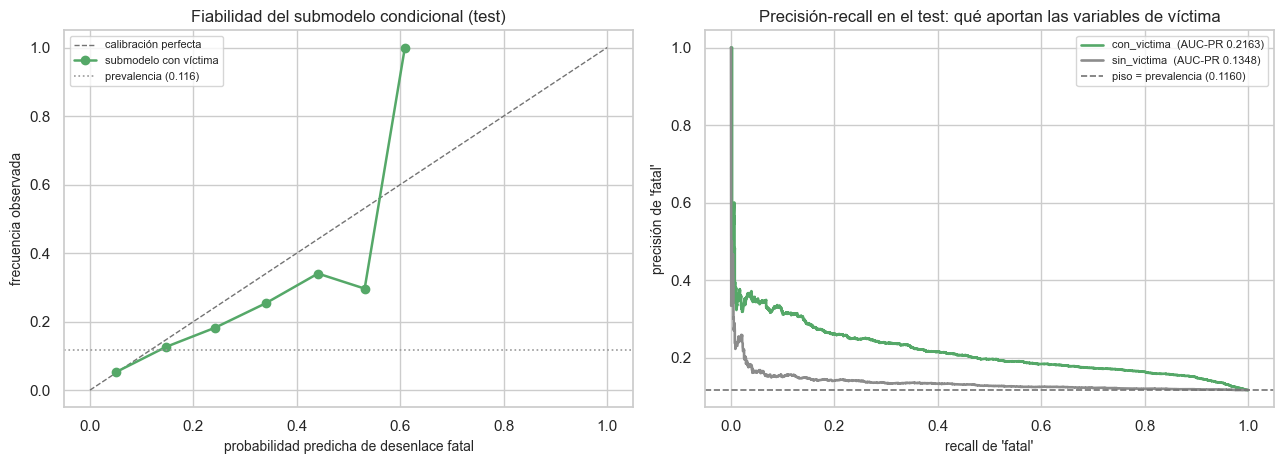

In [14]:
# ==========================================================================
# NB09 — 3.5 Calibración del submodelo
# ==========================================================================

print("Calibración del submodelo con variables de víctima (test)")
print("=" * 78)
p_fin = P_TEST["con_victima"]
y_fin = sub_test["y"].to_numpy()
tab_fiab = curva_fiabilidad(y_fin, p_fin)
print(f"{'bin':<14}{'n':>9}{'p media':>12}{'frec. obs':>12}{'desvío':>11}")
print("-" * 78)
for _, r in tab_fiab.iterrows():
    if r["n"] == 0:
        print(f"[{r['desde']:.1f},{r['hasta']:.1f})  {0:>9}{'—':>12}{'—':>12}{'—':>11}")
        continue
    print(f"[{r['desde']:.1f},{r['hasta']:.1f})  {int(r['n']):>9,}{r['p_media']:>12.4f}"
          f"{r['frec_obs']:>12.4f}{r['p_media']-r['frec_obs']:>+11.4f}")
print("-" * 78)
ECE_SUB = ece(y_fin, p_fin)
BRIER_SUB = brier_score_loss(y_fin, p_fin)
print(f"  ECE  : {ECE_SUB:.4f}")
print(f"  Brier: {BRIER_SUB:.4f}   (predecir siempre la prevalencia: "
      f"{brier_score_loss(y_fin, np.full(len(y_fin), piso_test)):.4f})")
print(f"  Media predicha {p_fin.mean():.4f} frente a prevalencia observada {piso_test:.4f}")
print("=" * 78)
print("Este submodelo se ajustó SIN class_weight (decisión D7), de modo que sus")
print("probabilidades sí pretenden estimar P(fatal | víctima, x) y la calibración")
print("es exigible, a diferencia de los modelos de la Sección 2.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
ax.plot([0, 1], [0, 1], "--", color="0.45", lw=1, label="calibración perfecta")
tt = tab_fiab[tab_fiab["n"] > 0]
ax.plot(tt["p_media"], tt["frec_obs"], "o-", color="#55a868", ms=6, lw=1.8,
        label="submodelo con víctima")
ax.axhline(piso_test, color="0.6", ls=":", lw=1.2,
           label=f"prevalencia ({piso_test:.3f})")
ax.set_xlabel("probabilidad predicha de desenlace fatal")
ax.set_ylabel("frecuencia observada")
ax.set_title("Fiabilidad del submodelo condicional (test)")
ax.legend(fontsize=8)

ax = axes[1]
for esquema, color in [("con_victima", "#55a868"), ("sin_victima", "#8c8c8c")]:
    pr, rc, _ = precision_recall_curve(sub_test["y"], P_TEST[esquema])
    ax.plot(rc, pr, lw=1.9, color=color,
            label=f"{esquema}  (AUC-PR {METRICAS_TEST[esquema]['auc_pr']:.4f})")
ax.axhline(piso_test, color="0.45", ls="--", lw=1.2,
           label=f"piso = prevalencia ({piso_test:.4f})")
ax.set_xlabel("recall de 'fatal'")
ax.set_ylabel("precisión de 'fatal'")
ax.set_title("Precisión-recall en el test: qué aportan las variables de víctima")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(DIR_FIGURES / "nb09_02_submodelo_calibracion_pr.png", dpi=150,
            bbox_inches="tight")
plt.show()

---

## 4. Interpretabilidad del submodelo

### 4.1 SHAP: qué se le pregunta y sobre cuántos casos

La importancia por impureza que reporta un Random Forest mide cuánto usó el algoritmo cada
variable, no cuánto aporta. Favorece además a las variables con más categorías, y aquí
`rango_etario` tiene trece mientras `es_feriado` tiene dos: la comparación estaría sesgada
desde el principio.

SHAP descompone cada predicción individual en contribuciones aditivas por variable, con
cálculo exacto para modelos de árbol. Permite dos cosas que la importancia por impureza no
alcanza: saber la dirección del efecto y contrastarlo contra lo que el análisis
exploratorio había encontrado por otra vía.

**Tamaño de la muestra: 500 casos.** NB04 documentó que `TreeExplainer` sobre bosques
profundos se vuelve intratable —el coste crece con el cuadrado de la profundidad y el
número de hojas— y adoptó ese tamaño. Se mantiene por dos razones. La primera es de
coherencia: el mismo criterio que NB04 aplicó a los modelos de tres clases. La segunda es
estadística: lo que se busca es un patrón global, es decir una media de atribuciones por
variable, y la precisión de una media crece con la raíz del tamaño muestral. Con 500 casos
el error estándar de esa media ronda un 4.5% de su desviación típica, suficiente para
ordenar variables cuyas importancias difieren en un factor de varias veces.

Lo que 500 casos **no** permiten es analizar subgrupos pequeños. Cualquier lectura por
categoría de `grupo_vulnerable` con pocos representantes en la muestra queda fuera de
alcance, y por eso el contraste de la subsección siguiente se hace sobre el conjunto
completo y no sobre la muestra de SHAP.

**Lo que cabe esperar, y que hay que verificar en vez de asumir.** Si las variables de
víctima son las que explican el aporte medido en la Sección 3, deberían dominar las
atribuciones. Si no lo hicieran, habría una contradicción entre dos mediciones del mismo
fenómeno y sería el hallazgo a explicar.

SHAP calculado sobre 500 casos en 44.9 s
  forma de las atribuciones: (500, 11)
  fatales en la muestra    : 60 de 500 (0.1200); prevalencia del test 0.1160

Importancia SHAP media absoluta frente a importancia por impureza
variable                    |SHAP| medio   peso relativo    impureza        origen
--------------------------------------------------------------------------------------
grupo_vulnerable                 0.06359           46.3%      0.2305       víctima
tipo_vehiculo                    0.01934           14.1%      0.0817      Matriz B
rango_etario                     0.01757           12.8%      0.2186       víctima
tipo_siniestro                   0.00824            6.0%      0.0718      Matriz B
factor_causante_grp              0.00776            5.6%      0.1650      Matriz B
dia_semana                       0.00736            5.4%      0.1158      Matriz B
es_lluviosa                      0.00440            3.2%      0.0392      Matriz B
condicion_via            

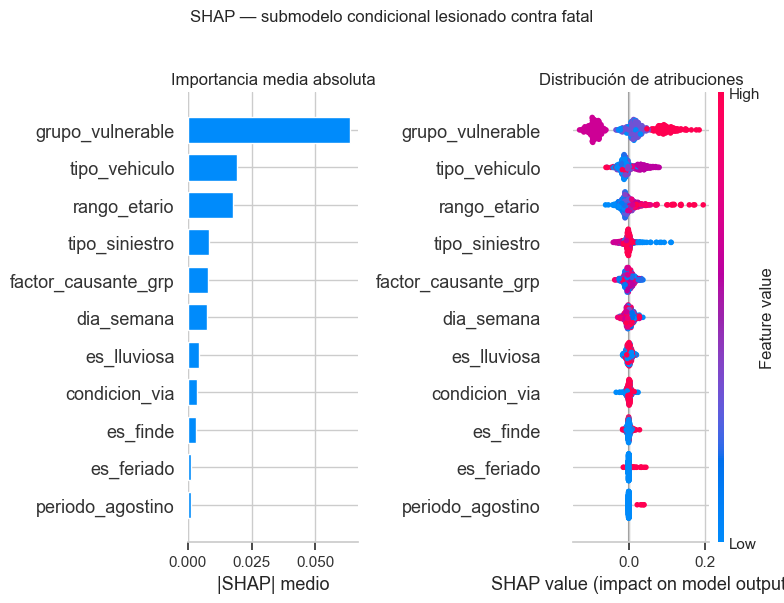

In [15]:
# ==========================================================================
# NB09 — 4.1 Atribuciones SHAP sobre el submodelo
# ==========================================================================

import shap

N_SHAP = 500
modelo_shap = MODELOS_FINAL["con_victima"]
cols_shap = ESQUEMAS["con_victima"]

rng = np.random.default_rng(SEED)
idx_shap = rng.choice(len(sub_test), size=min(N_SHAP, len(sub_test)), replace=False)
muestra = sub_test.iloc[idx_shap]
X_shap = diseno_sub(muestra, cols_shap)

t0 = time.time()
explicador = shap.TreeExplainer(modelo_shap)
vals = explicador.shap_values(X_shap, check_additivity=False)

# shap devuelve list[2] o ndarray (n, k, 2) segun version: se toma la clase positiva
if isinstance(vals, list):
    sv = np.asarray(vals[list(modelo_shap.classes_).index(1)])
elif np.asarray(vals).ndim == 3:
    sv = np.asarray(vals)[..., list(modelo_shap.classes_).index(1)]
else:
    sv = np.asarray(vals)
print(f"SHAP calculado sobre {len(X_shap):,} casos en {time.time()-t0:.1f} s")
print(f"  forma de las atribuciones: {sv.shape}")
print(f"  fatales en la muestra    : {int(muestra['y'].sum())} de {len(muestra)} "
      f"({muestra['y'].mean():.4f}); prevalencia del test {piso_test:.4f}")

imp_shap = (pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns)
              .sort_values(ascending=False))
total = imp_shap.sum()
imp_gini = pd.Series(modelo_shap.feature_importances_, index=X_shap.columns)

print("\nImportancia SHAP media absoluta frente a importancia por impureza")
print("=" * 86)
print(f"{'variable':<24}{'|SHAP| medio':>16}{'peso relativo':>16}"
      f"{'impureza':>12}{'origen':>14}")
print("-" * 86)
for v, x in imp_shap.items():
    origen = "víctima" if v in VICTIMA else "Matriz B"
    print(f"{v:<24}{x:>16.5f}{x/total*100:>15.1f}%{imp_gini[v]:>12.4f}{origen:>14}")
print("=" * 86)
peso_victima = float(imp_shap[VICTIMA].sum() / total)
print(f"  Peso conjunto de las variables de víctima: {peso_victima:.1%} de la atribución total")

fig = plt.figure(figsize=(12, 5.2))
ax1 = fig.add_subplot(1, 2, 1)
shap.summary_plot(sv, X_shap, plot_type="bar", show=False,
                  max_display=len(X_shap.columns))
ax1.set_title("Importancia media absoluta")
ax1.set_xlabel("|SHAP| medio")
ax2 = fig.add_subplot(1, 2, 2)
shap.summary_plot(sv, X_shap, show=False, max_display=len(X_shap.columns))
ax2.set_title("Distribución de atribuciones")
fig.suptitle("SHAP — submodelo condicional lesionado contra fatal", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(DIR_FIGURES / "nb09_03_shap_submodelo.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Contraste con NB02: una advertencia sobre la unidad de análisis

NB02 caracterizó la vulnerabilidad de los usuarios de la vía y dejó tres cifras que
conviene recuperar: los usuarios de motocicleta concentran el 42.0% de los fallecidos, los
peatones el 34.2%, y la letalidad del peatón —la proporción de sus víctimas que fallece—
es del 18.0%.

Sería tentador comparar esos porcentajes directamente contra lo que produce el submodelo y
declarar que se reproducen. **Sería un error, y la coincidencia numérica lo haría pasar
inadvertido.**

NB02 midió sobre `victimas.csv`, cuya unidad es la **víctima individual**. El submodelo
opera sobre `matriz_severidad.csv`, cuya unidad es el **siniestro**, y donde
`grupo_vulnerable` se definió como el usuario más vulnerable presente según un orden de
prioridad. Las dos unidades difieren en dos aspectos que empujan en direcciones opuestas:

- Un siniestro que involucra a un peatón y a un motociclista se etiqueta como `Peaton` por
  la regla de prioridad. El peatón absorbe casos que en el conteo por víctima se
  repartirían.
- Un siniestro de motocicleta aporta con frecuencia dos víctimas —conductor y
  acompañante—, de modo que el conteo por víctima infla al motociclista respecto del
  conteo por siniestro.

Lo comparable entre ambas fuentes no son los porcentajes sino **el ordenamiento de riesgo
y la dirección de los efectos**: que peatones y motociclistas sean los grupos de mayor
letalidad, muy por encima de los ocupantes de vehículo cerrado, y que la letalidad crezca
con la edad.

La celda siguiente calcula las dos versiones para que la diferencia quede a la vista y el
contraste se haga sobre lo que efectivamente es comparable.

In [16]:
# ==========================================================================
# NB09 — 4.2 Contraste con NB02 sobre las dos unidades de análisis
# ==========================================================================

print("Letalidad por grupo vulnerable — unidad: SINIESTRO (matriz_severidad)")
print("=" * 82)
print(f"{'grupo':<18}{'siniestros':>12}{'fatales':>10}{'letalidad':>12}"
      f"{'% de los fatales':>20}")
print("-" * 82)
t_sin = sub.groupby("grupo_vulnerable").agg(n=("y", "size"), fatales=("y", "sum"))
t_sin["letalidad"] = t_sin["fatales"] / t_sin["n"]
t_sin["pct_fatales"] = t_sin["fatales"] / t_sin["fatales"].sum()
t_sin = t_sin.sort_values("fatales", ascending=False)
for k, r in t_sin.iterrows():
    print(f"{k:<18}{int(r['n']):>12,}{int(r['fatales']):>10,}"
          f"{r['letalidad']:>12.4f}{r['pct_fatales']*100:>19.2f}%")
print("=" * 82)

print("\nNB02, unidad: VÍCTIMA individual (victimas.csv), valores publicados")
print("-" * 82)
print(f"  Usuarios de motocicleta : 42.0% de los fallecidos")
print(f"  Peatones                : 34.2% de los fallecidos")
print(f"  Letalidad del peatón    : 18.0%      del motociclista: 13.1%")
print("-" * 82)

orden_siniestro = list(t_sin.sort_values("letalidad", ascending=False).index)
print(f"\nOrdenamiento por letalidad, unidad siniestro : {orden_siniestro}")
print(f"Ordenamiento por letalidad según NB02         : "
      f"['Peaton', 'Motociclista', ...]  (peatón por encima de motociclista)")
coincide_orden = orden_siniestro[:2] == ["Peaton", "Motociclista"]
print(f"\n¿Coincide el ordenamiento de los dos grupos más letales? "
      f"{'SÍ' if coincide_orden else 'NO'}")
print("Los porcentajes NO son comparables entre unidades; el ordenamiento sí.")

# ------------------------------------------------------------------
# Dirección del efecto según SHAP, por categoría
# ------------------------------------------------------------------
print("\nDirección del efecto según SHAP (muestra de 500, atribución media por categoría)")
print("=" * 86)
for var in VICTIMA:
    j = list(X_shap.columns).index(var)
    print(f"\n  {var}")
    print(f"    {'categoría':<18}{'n en muestra':>14}{'SHAP medio':>14}{'letalidad global':>20}")
    filas = []
    for cat, codigo in zip(CAT_DTYPES_SUB[var].categories,
                           range(len(CAT_DTYPES_SUB[var].categories))):
        sel = (X_shap[var] == codigo).to_numpy()
        if sel.sum() == 0:
            continue
        let = float(sub.loc[sub[var].astype(str) == cat, "y"].mean())
        filas.append((cat, int(sel.sum()), float(sv[sel, j].mean()), let))
    for cat, n, s, let in sorted(filas, key=lambda x: -x[2]):
        print(f"    {cat:<18}{n:>14,}{s:>+14.4f}{let:>20.4f}")
print("=" * 86)
print("Una atribución SHAP positiva empuja la predicción hacia 'fatal'. Si el orden")
print("de las atribuciones sigue al de la letalidad observada, el modelo aprendió la")
print("relación que el EDA había descrito, por una vía independiente.")

Letalidad por grupo vulnerable — unidad: SINIESTRO (matriz_severidad)
grupo               siniestros   fatales   letalidad    % de los fatales
----------------------------------------------------------------------------------
Peaton                  10,455     2,398      0.2294              42.47%
Motociclista            13,907     2,086      0.1500              36.94%
Otro                    14,585       593      0.0407              10.50%
Ciclista                 4,158       570      0.1371              10.09%

NB02, unidad: VÍCTIMA individual (victimas.csv), valores publicados
----------------------------------------------------------------------------------
  Usuarios de motocicleta : 42.0% de los fallecidos
  Peatones                : 34.2% de los fallecidos
  Letalidad del peatón    : 18.0%      del motociclista: 13.1%
----------------------------------------------------------------------------------

Ordenamiento por letalidad, unidad siniestro : ['Peaton', 'Motociclista', 'Cicl

### 4.3 Un caso mal clasificado

NB04 mostró un caso mal clasificado en lugar de un acierto, con el argumento de que un
acierto confirma lo que ya se sabe mientras un error muestra dónde está el límite del
modelo. Se sigue el mismo criterio.

Se elige un **falso negativo**: un siniestro que resultó fatal y al que el submodelo
asignó una probabilidad baja. Es el error costoso —el que un sistema de análisis
retrospectivo pasaría por alto— y el más informativo sobre qué no captura el modelo.

LIME ajusta un modelo lineal en el entorno del caso, perturbando sus variables y
observando cómo cambia la predicción. A diferencia de SHAP, que atribuye sobre la
estructura del modelo, LIME responde una pregunta local: qué habría tenido que ser
distinto en **este** siniestro para que el modelo lo señalara.

In [17]:
# ==========================================================================
# NB09 — 4.3 Explicación local de un falso negativo (LIME)
# ==========================================================================

from lime.lime_tabular import LimeTabularExplainer

X_tr_sub = diseno_sub(sub_train, cols_shap)
X_te_sub = diseno_sub(sub_test, cols_shap)
idx_cat = [i for i, c in enumerate(cols_shap) if c in CAT_SUB]
nombres_cat = {i: [str(x) for x in CAT_DTYPES_SUB[cols_shap[i]].categories] for i in idx_cat}

# Falso negativo más extremo: observado fatal, probabilidad predicha más baja
p_final = P_TEST["con_victima"]
mask_fn = (sub_test["y"].to_numpy() == 1) & (p_final < UMBRAL)
pos_fn = np.where(mask_fn)[0]
elegido = int(pos_fn[np.argmin(p_final[pos_fn])])

caso = sub_test.iloc[elegido]
print("Caso elegido: falso negativo con la menor probabilidad asignada")
print("-" * 70)
print(f"  id_siniestro          : {caso['id_siniestro']}")
print(f"  fecha / franja        : {caso['fecha'].date()}  {caso['franja_horaria']}")
print(f"  distrito              : {caso['distrito_key']}")
print(f"  nivel_riesgo observado: {caso[TARGET_B]}")
print(f"  probabilidad predicha : {p_final[elegido]:.4f}   (umbral {UMBRAL:.4f})")
print(f"  falsos negativos      : {int(mask_fn.sum()):,} de "
      f"{int(sub_test['y'].sum()):,} fatales en el test")
print("-" * 70)
print("  Valores de las variables:")
for c in cols_shap:
    print(f"    {c:<24}{str(caso[c])}")

explicador_lime = LimeTabularExplainer(
    training_data=X_tr_sub.to_numpy(),
    feature_names=list(cols_shap),
    categorical_features=idx_cat,
    categorical_names=nombres_cat,
    class_names=["no fatal", "fatal"],
    discretize_continuous=False,
    random_state=SEED,
)
j_pos = list(modelo_shap.classes_).index(1)
exp = explicador_lime.explain_instance(
    X_te_sub.iloc[elegido].to_numpy(),
    lambda A: MODELOS_FINAL["con_victima"].predict_proba(
        pd.DataFrame(A, columns=cols_shap)),
    num_features=len(cols_shap), labels=(j_pos,),
)

print("\nContribuciones locales según LIME (positivo empuja hacia 'fatal')")
print("=" * 78)
print(f"{'condición':<52}{'peso':>12}{'dirección':>14}")
print("-" * 78)
for cond, peso in sorted(exp.as_list(label=j_pos), key=lambda x: -abs(x[1])):
    print(f"{cond[:51]:<52}{peso:>+12.4f}{('hacia fatal' if peso > 0 else 'hacia no fatal'):>14}")
print("=" * 78)
print(f"Intercepto local: {exp.intercept[j_pos]:.4f}   "
      f"R² del ajuste local: {exp.score:.4f}")
print("Un R² bajo indica que el entorno de este caso no se aproxima bien con un")
print("modelo lineal, lo que en sí mismo informa sobre la dificultad del caso.")

Caso elegido: falso negativo con la menor probabilidad asignada
----------------------------------------------------------------------
  id_siniestro          : SV-2025-076926
  fecha / franja        : 2025-12-07  Tarde (12-17)
  distrito              : cuscatancingo
  nivel_riesgo observado: fatal
  probabilidad predicha : 0.0053   (umbral 0.1494)
  falsos negativos      : 712 de 1,897 fatales en el test
----------------------------------------------------------------------
  Valores de las variables:
    factor_causante_grp     Distracción del Conductor
    tipo_siniestro          Colision
    tipo_vehiculo           Automovil
    condicion_via           Seca
    es_lluviosa             0
    es_finde                0
    dia_semana              6
    periodo_agostino        0
    es_feriado              0
    grupo_vulnerable        Otro
    rango_etario            16-20



Contribuciones locales según LIME (positivo empuja hacia 'fatal')
condición                                                   peso     dirección
------------------------------------------------------------------------------
grupo_vulnerable=Otro                                    -0.1319hacia no fatal
rango_etario=16-20                                       -0.0269hacia no fatal
tipo_vehiculo=Automovil                                  -0.0220hacia no fatal
tipo_siniestro=Colision                                  -0.0103hacia no fatal
factor_causante_grp=Distracción del Conductor            -0.0065hacia no fatal
condicion_via=Seca                                       -0.0018hacia no fatal
dia_semana=6                                             +0.0011   hacia fatal
periodo_agostino                                         +0.0009   hacia fatal
es_feriado                                               -0.0006hacia no fatal
es_lluviosa                                              +0.0004

### 4.4 Lectura de la interpretabilidad

**Las variables de víctima dominan, y la importancia por impureza lo habría ocultado.**

| Variable | \|SHAP\| medio | Peso | Impureza | Origen |
|---|---|---|---|---|
| `grupo_vulnerable` | 0.06359 | **46.3%** | 0.2305 | víctima |
| `tipo_vehiculo` | 0.01934 | 14.1% | 0.0817 | Matriz B |
| `rango_etario` | 0.01757 | 12.8% | 0.2186 | víctima |
| `tipo_siniestro` | 0.00824 | 6.0% | 0.0718 | Matriz B |
| `factor_causante_grp` | 0.00776 | 5.6% | 0.1650 | Matriz B |

Las dos variables de víctima reúnen el **59.1%** de la atribución total, coherente con el
salto de AUC-PR de la Sección 3 medido por una vía completamente distinta.

El contraste entre las dos columnas de importancia es instructivo. Por impureza,
`grupo_vulnerable` y `rango_etario` están casi empatadas: 0.2305 y 0.2186. Por SHAP, la
primera pesa más del triple que la segunda: 46.3% contra 12.8%. La diferencia se explica
porque `rango_etario` tiene trece categorías y `grupo_vulnerable` cuatro, y la impureza
premia a las variables con más cortes posibles. Es el mismo fenómeno que NB07 encontró con
`poblacion_baja`, en dirección contraria: allí la impureza subestimaba una variable útil,
aquí sobrestima una de aporte moderado.

**El ordenamiento reproduce a NB02 por una vía independiente.**

| Grupo | SHAP medio | Letalidad observada |
|---|---|---|
| Peatón | +0.0991 | 0.2294 |
| Motociclista | +0.0145 | 0.1500 |
| Ciclista | +0.0108 | 0.1371 |
| Otro | −0.0904 | 0.0407 |

La concordancia de rangos es **exacta**: el orden de las atribuciones coincide con el de
la letalidad observada en los cuatro grupos. Para `rango_etario`, la correlación de
Spearman entre la atribución media y la letalidad por categoría es de **0.9560** sobre
trece categorías, con la atribución máxima en el grupo de 71 años o más —letalidad de
0.2982— y la mínima en 0–15 años —0.0900—.

Conviene ser preciso sobre qué valida esto. El modelo no descubrió nada que el EDA no
hubiera visto: NB02 ya había documentado que el peatón es el usuario más letal y que la
letalidad crece con la edad. Lo que la coincidencia establece es que **el submodelo
aprendió la estructura correcta y no un atajo**. Un modelo que hubiera encontrado una
correlación espuria produciría un ordenamiento distinto, y aquí no ocurre. Es una
verificación de consistencia entre dos etapas del proyecto que usaron datos, unidades de
análisis y métodos diferentes.

Y como advirtió la Sección 4.2, la coincidencia es de **ordenamiento**, no de magnitud: la
letalidad del peatón es 0.2294 por siniestro y 0.180 por víctima según NB02. Los dos
números son correctos y miden cosas distintas.

**El caso mal clasificado muestra el límite con claridad.**

El falso negativo más extremo del conjunto de prueba es el siniestro `SV-2025-076926`
—Cuscatancingo, 7 de diciembre de 2025, franja de tarde—, con desenlace fatal y una
probabilidad asignada de **0.0053** frente a un umbral de 0.1494.

LIME descompone esa predicción y el resultado es que **todas las variables relevantes
empujaron hacia «no fatal»**: `grupo_vulnerable = Otro` con un peso de −0.1319,
`rango_etario = 16-20` con −0.0269, `tipo_vehiculo = Automovil` con −0.0220,
`tipo_siniestro = Colision` con −0.0103, vía seca, sin lluvia, sin feriado. El perfil es el
de menor letalidad observada del conjunto: un ocupante joven de automóvil en una colisión
en condiciones normales, cuya letalidad empírica es de 0.0407.

El modelo no se equivocó por falta de información sobre este caso: se equivocó porque el
caso es genuinamente atípico dentro de su categoría. Son 712 los falsos negativos entre
los 1,897 siniestros fatales del período de prueba, y buena parte corresponde a este mismo
patrón —fatalidades en perfiles de bajo riesgo—. Ninguna de las variables disponibles
distingue una colisión de automóvil que resulta mortal de una que no lo es; harían falta
velocidad de impacto, uso de cinturón o tiempo de respuesta de la atención médica, que el
conjunto de datos no contiene.

El R² del ajuste local de LIME es 0.4901, un valor moderado que indica que ni siquiera el
entorno inmediato de este caso se aproxima bien con un modelo lineal. Es coherente con lo
anterior: el caso está en una región donde el modelo no tiene estructura que ofrecer.

---

## 5. Qué significa esto para el producto

### 5.1 Por qué el submodelo no entra en el prototipo predictivo

El prototipo de la Etapa 2 predice **frecuencia**: cuántos siniestros cabe esperar en un
distrito, una fecha y una franja horaria. Todas sus variables —lluvia, fin de semana,
feriado, período agostino, urbanización, exposición— son conocibles con anticipación. Esa
es la condición que lo hace operativo.

Las variables del submodelo no cumplen esa condición, y la diferencia es de naturaleza, no
de grado:

| Variable | Cuándo se conoce |
|---|---|
| `tipo_siniestro` | Al ocurrir el hecho |
| `tipo_vehiculo` | Al ocurrir el hecho |
| `factor_causante_grp` | Tras la investigación del hecho |
| `grupo_vulnerable` | Tras identificar a las víctimas |
| `rango_etario` | Tras identificar a las víctimas |

No existe ninguna manera de conocer el tipo de usuario afectado antes de que exista el
afectado. Pedirle al submodelo una predicción ex ante es pedirle que anticipe su propio
condicionante.

Esto no es una limitación del modelo: es la definición del problema. Y explica por qué el
F1-macro de 0.3247 que NB04 obtuvo sobre tres clases no es un mal resultado sino el techo
de lo predecible sin saber quién se accidentó.

### 5.2 Para qué sí sirve

Descartado el uso predictivo, quedan tres usos que el desempeño medido sostiene, ordenados
de mayor a menor respaldo empírico.

**Primero: cuantificar dónde se concentra la letalidad, para orientar política pública.**

Es el uso mejor respaldado y no requiere que el modelo prediga bien ningún caso
individual. Los números que produce este notebook son directamente utilizables:

| Grupo | Siniestros con víctima | Letalidad |
|---|---|---|
| Peatón | 10,455 | **0.2294** |
| Motociclista | 13,907 | 0.1500 |
| Ciclista | 4,158 | 0.1371 |
| Ocupante de vehículo | 14,585 | 0.0407 |

Un peatón involucrado en un siniestro tiene **5.6 veces** la probabilidad de morir que un
ocupante de vehículo cerrado. Esa razón, junto con el gradiente por edad —de 0.0900 en
menores de 15 años a 0.2982 en mayores de 70—, identifica a los grupos sobre los que una
intervención tiene mayor rendimiento esperado: infraestructura peatonal, cruces seguros,
pacificación del tránsito en entornos de alta circulación a pie.

El submodelo aporta aquí algo que la tabla de frecuencias no da por sí sola: confirma que
esas asociaciones se sostienen **controlando por el resto de variables**. El peatón no
aparece como más letal por estar sobrerrepresentado en colisiones graves o en ciertos
tipos de vía, sino que su efecto persiste cuando el modelo tiene acceso simultáneo a
factor causante, tipo de siniestro, tipo de vehículo y condición de la vía.

**Segundo: estratificar el análisis retrospectivo.**

Aplicado sobre siniestros ya ocurridos, el submodelo ordena por riesgo estimado y permite
preguntas que el conteo crudo no responde. Un ejemplo concreto que este notebook deja
abierto: los 712 falsos negativos —fatalidades en perfiles de bajo riesgo estimado— son
exactamente el conjunto que merece revisión cualitativa, porque son las muertes que las
variables disponibles no explican. Ese filtro es útil aunque la precisión del modelo sea
baja, porque el criterio de selección no es «acertar» sino «señalar lo anómalo».

**Tercero, y con reservas: complementar el mapa de frecuencia.**

El prototipo predice cuántos siniestros habrá. Podría acompañar esa cifra con la
composición histórica de víctimas del distrito, que es un dato observado y no una
predicción. Un distrito con alta frecuencia y alta proporción histórica de peatones
involucrados enfrenta un problema distinto que otro con la misma frecuencia y
predominio de colisiones entre vehículos.

La reserva es importante: eso **no es usar el submodelo**, es usar la tabla de letalidad
que el submodelo ayudó a validar. Presentarlo como una predicción de gravedad sería
exactamente el error que la Sección 5.1 descarta.

**Un uso que hay que descartar explícitamente.** Con una precisión de 0.1818, el submodelo
no sirve para priorizar la respuesta de emergencia caso a caso. De cada seis siniestros
que señalaría, cinco no son fatales. Un sistema de despacho construido sobre esa base
asignaría recursos críticos con una tasa de error inaceptable.

---

## 6. Cierre

In [18]:
# ==========================================================================
# NB09 — 6.1 Persistencia de artefactos
# ==========================================================================

ARTEFACTOS_NB09 = {}


def guardar_modelo(objeto, nombre):
    ruta = DIR_MODELS / nombre
    if ruta.exists():
        raise FileExistsError(f"{nombre} ya existe. NB09 no sobrescribe artefactos.")
    joblib.dump(objeto, ruta, compress=3)
    mb_ = ruta.stat().st_size / 1024**2
    ARTEFACTOS_NB09[f"models/{nombre}"] = mb_
    print(f"  models/{nombre:<44}{mb_:>9.2f} MB")
    return ruta


print("Modelos")
ruta_sub = guardar_modelo(MODELOS_FINAL["con_victima"], "severidad_condicional_nb09.pkl")
ruta_sub_sin = guardar_modelo(MODELOS_FINAL["sin_victima"],
                              "severidad_condicional_sin_victima_nb09.pkl")
calibrador_aceptado = {k: v["aceptada"] for k, v in RESULTADO_CALIBRACION.items()}
if any(calibrador_aceptado.values()):
    for clave, acept in calibrador_aceptado.items():
        if acept:
            guardar_modelo(calibrados[clave], f"severidad_calibrador_{clave}_nb09.pkl")
else:
    print("  (ningún calibrador alcanzó el criterio D3: no se persiste ninguno)")

# ------------------------------------------------------------------
# Especificación: el esquema normativo de columnas, junto al modelo
# ------------------------------------------------------------------
ESPECIFICACION = {
    "notebook": "NB09_calibracion_y_submodelo_severidad",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "seed": SEED,
    "matriz": "matriz_severidad.csv",
    "unidad_observacion": "siniestro individual",
    "split": {"train": "2022-01-01 a 2024-12-31", "test": "2025-01-01 a 2026-06-30",
              "columna": "split", "origen": "NB03, no alterado"},
    "particion_interna": {
        "seccion_2": {"ajuste": 2022, "calibracion": 2023, "decision": 2024},
        "seccion_3": {"ajuste": "2022-2023", "validacion": 2024},
    },
    "modelos": {
        "severidad_condicional_nb09.pkl": {
            "algoritmo": "RandomForestClassifier",
            "tarea": "binaria: fatal (1) contra con_lesionados (0)",
            "universo": "siniestros con victima (nivel_riesgo != solo_danos)",
            "columnas": list(ESQUEMAS["con_victima"]),
            "categoricas": list(CAT_SUB),
            "codificacion": "cat.codes con categorias fijadas por el bloque de ajuste; "
                            "categoria no vista -> -1",
            "categorias_por_columna": {c: [str(x) for x in CAT_DTYPES_SUB[c].categories]
                                       for c in CAT_SUB},
            "hiperparametros": {k: v for k, v in PARAMS_SUB.items() if k != "n_jobs"},
            "class_weight": None,
            "umbral_operacion": UMBRAL,
            "umbral_seleccionado_en": "validacion 2024, maximo F1 de la clase fatal",
            "advertencia": "El umbral NO esta dentro del objeto serializado.",
        },
        "severidad_condicional_sin_victima_nb09.pkl": {
            "algoritmo": "RandomForestClassifier",
            "proposito": "control de ablacion; no es un modelo de produccion",
            "columnas": list(ESQUEMAS["sin_victima"]),
        },
    },
    "modelos_nb04_consumidos": {
        "severidad_logistica.pkl": {"codificacion": "get_dummies(drop_first=True)",
                                    "columnas": list(Xtr_ohe.columns)},
        "severidad_random_forest.pkl": {"codificacion": "cat.codes con mapeo de train",
                                        "columnas": list(Xtr_cod.columns)},
        "nota": "classes_ de ambos es alfabetico y NO coincide con el orden declarado "
                "en NB04; indexar predict_proba por classes_ del modelo.",
    },
}
ruta_espec = DIR_RESULTS / "nb09_especificacion.json"
ruta_espec.write_text(json.dumps(ESPECIFICACION, indent=2, ensure_ascii=False),
                      encoding="utf-8")
print(f"\nEspecificación: {ruta_espec.relative_to(ROOT)}")

# ------------------------------------------------------------------
# Métricas
# ------------------------------------------------------------------
METRICAS = {
    "notebook": "NB09_calibracion_y_submodelo_severidad",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "seed": SEED,
    "seccion_2_calibracion": {
        "desplazamiento_prior": resumen_prior,
        "brier_por_clase": brier,
        "ece": {k: {c: ECE[k][c] for c in list(CLASES_B) + ["medio"]} for k in ECE},
        "rango_p05_p95_medio": {"logistica_multinomial": r_log, "random_forest": r_rf},
        "correccion_platt": {k: {kk: vv for kk, vv in v.items()}
                             for k, v in RESULTADO_CALIBRACION.items()},
        "criterio_D3_reduccion_ece_relativa": UMBRAL_ECE_REL,
    },
    "seccion_3_submodelo": {
        "universo": {"registros": int(len(sub)),
                     "prevalencia_global_fatal": float(sub["y"].mean()),
                     "train": int(len(sub_train)), "test": int(len(sub_test)),
                     "ajuste": int(len(sub_aju)), "validacion": int(len(sub_val))},
        "validacion_2024": {
            esquema: {"auc_pr": float(average_precision_score(sub_val["y"], P_VAL[esquema])),
                      "roc_auc": float(roc_auc_score(sub_val["y"], P_VAL[esquema])),
                      "piso": piso_val}
            for esquema in ESQUEMAS},
        "bootstrap_validacion": BOOT_VAL,
        "test": METRICAS_TEST,
        "bootstrap_test": BOOT_TEST,
        "piso_test": piso_test,
        "calibracion_submodelo": {"ece": ECE_SUB, "brier": BRIER_SUB},
    },
    "seccion_4_interpretabilidad": {
        "n_shap": int(len(X_shap)),
        "importancia_shap": {k: float(v) for k, v in imp_shap.items()},
        "peso_variables_victima": peso_victima,
        "letalidad_por_grupo_unidad_siniestro": {
            k: {"n": int(r["n"]), "fatales": int(r["fatales"]),
                "letalidad": float(r["letalidad"])} for k, r in t_sin.iterrows()},
        "caso_lime": {"id_siniestro": str(caso["id_siniestro"]),
                      "probabilidad": float(p_final[elegido]),
                      "r2_local": float(exp.score)},
    },
}
ruta_met = DIR_RESULTS / "nb09_metricas.json"
ruta_met.write_text(json.dumps(METRICAS, indent=2, ensure_ascii=False, default=str),
                    encoding="utf-8")
print(f"Métricas      : {ruta_met.relative_to(ROOT)}")

Modelos


  models/severidad_condicional_nb09.pkl                  15.43 MB


  models/severidad_condicional_sin_victima_nb09.pkl      12.33 MB
  models/severidad_calibrador_logistica_multinomial_nb09.pkl     0.00 MB


  models/severidad_calibrador_random_forest_nb09.pkl     28.74 MB

Especificación: reports/results/nb09_especificacion.json
Métricas      : reports/results/nb09_metricas.json


In [19]:
# ==========================================================================
# NB09 — 6.2 Verificación final de integridad y resumen de cierre
# ==========================================================================

hashes_finales = {c: sha256_archivo(r) for c, (r, _) in ARTEFACTOS_PREVIOS.items()
                  if r.is_file()}
alterados = [c for c in HASHES_INICIALES
             if HASHES_INICIALES[c] != hashes_finales.get(c)]
if alterados:
    raise RuntimeError(
        f"Artefactos previos alterados durante la ejecución: {alterados}. "
        "Restaurar con git checkout."
    )
print(f"Integridad de artefactos previos: verificada "
      f"({len(hashes_finales)} archivos intactos)")

print("\n" + "=" * 80)
print("NB09 — CIERRE")
print("=" * 80)

print("\nSección 2 — calibración del clasificador de tres clases")
print("-" * 80)
for clave in MODELOS_NB04:
    print(f"  {etiq[clave]:<16}ECE medio {ECE[clave]['medio']['ancho_igual']:.4f}   "
          f"Brier medio {brier[clave]['medio']:.4f}   "
          f"corrección Platt: "
          f"{'ACEPTADA' if RESULTADO_CALIBRACION[clave]['aceptada'] else 'RECHAZADA'}")

print("\nSección 3 — submodelo condicional lesionado contra fatal")
print("-" * 80)
print(f"{'esquema':<16}{'AUC-PR test':>13}{'lift':>8}{'ROC-AUC':>10}{'recall fatal':>14}")
for esquema in ESQUEMAS:
    m = METRICAS_TEST[esquema]
    print(f"{esquema:<16}{m['auc_pr']:>13.4f}{m['lift']:>8.3f}"
          f"{m['roc_auc']:>10.4f}{m['recall_fatal']:>14.4f}")
print(f"{'piso':<16}{piso_test:>13.4f}{1.0:>8.3f}{0.5:>10.4f}")
print(f"\n  Δ AUC-PR (con − sin) en test : {BOOT_TEST['delta_puntual']:+.4f}")
print(f"  IC {NIVEL_IC:.0%}                       : "
      f"[{BOOT_TEST['ic_inf']:+.4f}, {BOOT_TEST['ic_sup']:+.4f}]")
print(f"  Criterio D6                   : "
      f"{'CUMPLIDO' if BOOT_TEST['excluye_cero'] else 'NO CUMPLIDO'}")

print("\nSección 4 — interpretabilidad")
print("-" * 80)
print(f"  Variables de víctima: {peso_victima:.1%} de la atribución SHAP total")
print(f"  Variable dominante  : {imp_shap.index[0]}")

print("\nArtefactos generados")
print("-" * 80)
for nombre, mb_ in ARTEFACTOS_NB09.items():
    print(f"  {nombre:<56}{mb_:>9.2f} MB")
for r in [ruta_espec, ruta_met, RUTA_DECISIONES, RUTA_HASHES]:
    print(f"  {str(r.relative_to(ROOT)):<56}{r.stat().st_size/1024**2:>9.2f} MB")
for f in sorted(DIR_FIGURES.glob("nb09_*.png")):
    print(f"  {str(f.relative_to(ROOT)):<56}{f.stat().st_size/1024**2:>9.2f} MB")
print("=" * 80)

Integridad de artefactos previos: verificada (19 archivos intactos)

NB09 — CIERRE

Sección 2 — calibración del clasificador de tres clases
--------------------------------------------------------------------------------
  Logística       ECE medio 0.1787   Brier medio 0.2197   corrección Platt: ACEPTADA
  Random Forest   ECE medio 0.1663   Brier medio 0.2250   corrección Platt: ACEPTADA

Sección 3 — submodelo condicional lesionado contra fatal
--------------------------------------------------------------------------------
esquema           AUC-PR test    lift   ROC-AUC  recall fatal
sin_victima            0.1348   1.162    0.5357        0.4365
con_victima            0.2163   1.865    0.6835        0.6247
piso                   0.1160   1.000    0.5000

  Δ AUC-PR (con − sin) en test : +0.0815
  IC 95%                       : [+0.0689, +0.0942]
  Criterio D6                   : CUMPLIDO

Sección 4 — interpretabilidad
--------------------------------------------------------------------

### 6.3 Limitaciones y cierre

**Lo que el notebook establece.**

1. Las probabilidades de los clasificadores de NB04 no estiman P(clase | x): están
   alineadas con una distribución uniforme de clases por efecto de
   `class_weight='balanced'`. La distancia de la logística a la uniforme es de 0.0060
   frente a 0.1787 a la frecuencia real.
2. Ese desajuste es un desplazamiento de prior, no un defecto estructural: una sigmoide de
   dos parámetros reduce el ECE entre un 95.0% y un 98.3% y mejora además el Brier.
3. Condicionando sobre que hubo víctima, las variables de víctima aportan **+0.0815** de
   AUC-PR sobre el test, con IC 95% de [+0.0689, +0.0942]. El recall de `fatal` pasa de
   0.4365 a 0.6247 con menos falsos positivos.
4. Sin esas variables, el submodelo está prácticamente en el azar: AUC-PR de 0.1348 sobre
   un piso de 0.1160, ROC-AUC de 0.5357.
5. SHAP reproduce el ordenamiento de letalidad de NB02 por una vía independiente:
   concordancia exacta en `grupo_vulnerable` y Spearman de 0.9560 en `rango_etario`.

**Limitaciones declaradas.**

| Limitación | Evidencia | Implicación |
|---|---|---|
| La corrección de calibración se demostró sobre gemelos, no sobre los artefactos de NB04 | Los gemelos se entrenaron sobre 2022, un tercio de train | Queda establecido que el procedimiento funciona, no que los modelos publicados estén calibrados |
| El submodelo sobreestima el nivel en el test | Media predicha 0.1391 contra prevalencia 0.1160 | La letalidad descendió de 0.1526 en 2022 a 0.1140 en 2025. Es desplazamiento temporal, del tipo que NB05 corrigió para frecuencia y aquí no se corrige |
| Precisión baja en términos absolutos | 0.1818 con el umbral de operación | Inutilizable para decisiones caso a caso. Ver Sección 5.2 |
| Variables ex post | `grupo_vulnerable` y `rango_etario` se conocen tras identificar a las víctimas | El submodelo no admite uso predictivo. No es corregible: es la definición del problema |
| El submodelo rompe la continuidad con NB04 | Decisión D7: sin `class_weight` | Sus métricas no son comparables en igualdad de condiciones con las de los clasificadores de tres clases |
| Unidad de análisis distinta de NB02 | Letalidad del peatón 0.2294 por siniestro contra 0.180 por víctima | Los porcentajes de ambas fuentes no son intercambiables. Solo el ordenamiento lo es |
| 712 fatalidades sin explicar | Falsos negativos en perfiles de bajo riesgo | Faltan variables —velocidad de impacto, uso de cinturón, tiempo de respuesta médica— que el conjunto no contiene |
| Naturaleza sintética del conjunto | Calibrado sobre agregados ONASEVI/FONAT en NB01 | Toda validación externa exige contrastar contra registros reales |

**Qué queda para lo que sigue.**

- **Calibrar los artefactos de NB04 de verdad**, con validación cruzada sobre todo el
  período de entrenamiento en lugar de gemelos sobre un año. El procedimiento ya está
  verificado; falta aplicarlo a escala.
- **Corregir el desplazamiento temporal de la letalidad** en el submodelo, siguiendo la
  misma lógica que NB05 aplicó a la frecuencia.
- **Revisar cualitativamente los 712 falsos negativos.** Es el conjunto donde las
  variables disponibles fallan, y por tanto el que indica qué habría que medir.
- **Decidir si la tabla de letalidad por grupo entra en el prototipo** como dato
  descriptivo del distrito. Es la única vía por la que este notebook llega al producto, y
  exige presentarla como composición histórica observada, nunca como predicción.